# 관련 단축키 설명

## 셀 코드 실행

* Shift + Enter: 현재 셀을 실행하고 다음 셀로 이동합니다. (가장 많이 사용)

* Ctrl + Enter: 현재 셀을 실행하고 현재 셀에 머무릅니다. 결과를 확인하고 코드를 계속 수정할 때 유용합니다. (Mac: Cmd + Enter)

## 코드 셀 만들기

* A: 현재 셀 위(Above)에 새로운 코드 셀을 추가합니다.

* B: 현재 셀 아래(Below)에 새로운 코드 셀을 추가합니다.

* Y: 마크다운 등 다른 타입의 셀을 다시 코드(Code) 셀로 변경합니다.

* M: 현재 셀을 마크다운(Markdown) 셀로 변경합니다.

* D , D: 키보드 알파벳 D를 연속으로 두 번 타닥 누르면 셀이 삭제됩니다.

보통 마크다운 셀을 새로 만들 때는 **B**를 눌러 아래에 빈 코드 셀을 만든 직후, 바로 **M**을 눌러 마크다운 셀로 변환해서 글을 작성하는 방식을 가장 많이 사용

<hr style="height: 5px; background-color: #39FF14; border: none;">

# **비전 노드 개발 관련 실험코드**

### 리얼센스 D435IF 기반 듀플로 단일 블럭 및 조립 객체 인식 상태 개발

주피터 노트북 -> 파이썬 라이브러리 변환 구조

## library requirement

In [ ]:
# !python --version
# !pip freeze > requirements.txt
# !cat requirements.txt
# 만약 requirement 설치시
# !python3 -m pip install -r requirements.txt

In [ ]:
# %pip install -r requirements.txt

<hr style="height: 5px; background-color: #39FF14; border: none;">

## **[윈도우 작업] - 그래픽 카드 쿠다 설정**

In [ ]:
# # 기존 토치 비전 삭제
# %pip uninstall -y torch torchvision torchaudio

In [ ]:
# # 파이토치 패키지 설치
# %pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --no-cache-dir

In [8]:
import sys
import subprocess

print("=== 🖥️ 1. 시스템 및 그래픽카드 정보 (nvidia-smi) ===")
try:
    # 윈도우에 설치된 NVIDIA 드라이버 정보 출력
    result = subprocess.run(['nvidia-smi'], stdout=subprocess.PIPE, text=True)
    print(result.stdout)
except FileNotFoundError:
    print("⚠️ nvidia-smi 명령어를 찾을 수 없습니다. NVIDIA 드라이버가 없거나 환경변수에 등록되지 않았습니다.")

print("\n=== 🧠 2. 현재 파이썬 및 파이토치 환경 ===")
print(f"Python 실행 경로: {sys.executable}")
print(f"Python 버전: {sys.version.split(' ')[0]}")

try:
    import torch
    print(f"\nPyTorch 패키지 위치: {torch.__file__}")
    print(f"PyTorch 버전: {torch.__version__}")
    print(f"PyTorch 내장 CUDA 버전: {torch.version.cuda}")
    print(f"CUDA (GPU) 활성화 여부: {torch.cuda.is_available()}")
    
    if torch.cuda.is_available():
        print(f"사용 가능한 GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("⚠️ 진단 결과: 현재 파이토치는 GPU를 인식하지 못하는 'CPU 전용 버전'입니다.")
except ImportError:
    print("\n⚠️ 현재 환경에 파이토치(torch)가 설치되어 있지 않습니다.")

=== 🖥️ 1. 시스템 및 그래픽카드 정보 (nvidia-smi) ===
Sun May 31 03:00:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2060      WDDM  |   00000000:01:00.0  On |                  N/A |
| 32%   46C    P0             39W /  190W |    2004MiB /   6144MiB |      6%      Default |
|                                         |                        |                  N/A |
+-----

### **쿠다 설치 위치 확인**
* 만약 쿠다 설치가 잘못되었다고 생각되면 위에 셀을 통해서 위치랑 실행 위치 확인하기
* 다시 설치후, VSCODE 재실행

In [ ]:
## 파이토치 위치 불일치시 삭제용 코드

# import sys
# import subprocess

# packages = ["torch", "torchvision", "torchaudio"]

# print("🔥 좀비 파이토치 강제 박멸을 시작합니다...")
# for i in range(3):
#     print(f"🧹 삭제 시도 {i+1}회차...")
#     result = subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y"] + packages, capture_output=True, text=True)
#     if "Found existing installation" in result.stdout:
#         print(f"   -> 찌꺼기 발견 및 삭제 완료!")
#     elif "not installed" in result.stderr or "not installed" in result.stdout:
#         print(f"   -> 깨끗합니다 (더 이상 지울 게 없음).")

# print("✅ 완벽하게 지워졌습니다! 이제 2단계를 진행하세요.")

<hr style="height: 5px; background-color: #39FF14; border: none;">

## **라이브러리 변환**

In [ ]:
# 요구사항 설치
# %pip install -r requirements.txt

In [ ]:
# !pip install nbconvert
# !jupyter nbconvert --to script test.ipynb
# !pip install scikit-learn

Unable to create process using 'C:\Users\ULTIMATE NIGHTMARE\.conda\envs\PythonProject2\python.exe "C:\Users\ULTIMATE NIGHTMARE\.conda\envs\PythonProject2\Scripts\pip-script.py" install scikit-learn'


In [9]:
%pip install scikit-learn
%pip install nbconvert
# %jupyter nbconvert --to script test.ipynb

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [8]:
# scipy.ndimage.median_filter
import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

print("\n라이브러리 로드")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

라이브러리 로드


<hr style="height: 5px; background-color: #39FF14; border: none;">

## **욜로 확인용 코드**

In [9]:
# import cv2
# from ultralytics import YOLO

def yolo_check(model_path, image_path):
    """
    YOLO 모델과 이미지 경로를 받아 추론을 수행하고,
    결과가 그려진 RGB 이미지를 반환합니다.
    """
    # 1. 모델 로드
    print(f"🤖 '{model_path}' 로딩 중...")
    model = YOLO(model_path)

    # 2. GPU 할당 확인
    model.to('cuda')
    print(f"🚀 모델이 사용하는 하드웨어: {model.device}")

    # 3. 테스트 이미지 추론 (save=False로 변경하여 디스크 저장 생략, 메모리에서 바로 처리)
    print(f"🔍 추론 시작 (RTX 2060 가동)...")
    results = model.predict(source=image_path, save=False, conf=0.5, device=0)

    # 4. 결과 요약 출력
    result = results[0] # 첫 번째 이미지에 대한 결과 객체
    print(f"\n✅ 발견된 객체 수: {len(result.boxes)}")
    if result.masks is not None:
        print(f"🎨 추출된 마스크(폴리곤) 수: {len(result.masks)}")

    # 5. 결과 이미지 배열 뽑아내기 및 색상 변환
    # result.plot() 은 예측 박스와 마스크가 그려진 OpenCV BGR 배열을 바로 뱉어냅니다!
    annotated_bgr = result.plot() 
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB) # BGR -> RGB 변환

    return annotated_rgb

In [10]:
%pwd

'c:\\Users\\ULTIMATE NIGHTMARE\\Desktop\\test\\pointcloud_test'

In [ ]:
model_name = 'yolov8n-seg.pt'
test_image_url = 'https://ultralytics.com/images/bus.jpg'
title = 'yolo segmentation result'

results_y = yolo_check(model_name, test_image_url)

figsize=(18, 6)
fig, axes = plt.subplots(1, 1, figsize = figsize)

axes.imshow(results_y)
axes.set_title(title)
axes.axis("off")

plt.tight_layout()
plt.show()

<hr style="height: 5px; background-color: #39FF14; border: none;">

# **리얼센스 카메라 인식 하는 함수**

### **카메라 렌즈 왜곡 모델**

distortion.inverse_brown_conrady

RealSense SDK에서 쓰는 distortion model 중 하나로 **렌즈 왜곡을 보정, 역보정용 수학 모델**

RealSense intrinsics 내 정보

fx, fy   = 초점거리
cx, cy   = 주점 principal point
model    = 렌즈 왜곡 모델
coeffs   = 왜곡 계수

coeffs:
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

 = 실제 계산에서는 왜곡이 없다

### **뎁스 스케일**
depth raw 값의 단위 변환 계수

depth_scale: 0.0010000000474974513

RealSense depth image 보통 uint16 raw 값 저장

예를 들어 depth 픽셀 값으로 : 500

실제 거리는: 500 * 0.001 = 0.5 m

즉: z_m = depth_raw[v, u] * depth_scale

In [12]:
def list_realsense_devices():
    """
    현재 연결된 Intel RealSense 카메라 목록을 출력하는 함수
    """
    ctx = rs.context()
    devices = ctx.query_devices()

    device_count = len(devices)

    print(f"[INFO] 연결된 RealSense 장치 수: {device_count}")

    if device_count == 0:
        print("[WARN] 연결된 RealSense 카메라가 없습니다.")
        return []

    device_info_list = []

    for i, dev in enumerate(devices):
        print("\n" + "=" * 50)
        print(f"[DEVICE {i}]")

        info = {}

        for info_type in [
            rs.camera_info.name,
            rs.camera_info.serial_number,
            rs.camera_info.firmware_version,
            rs.camera_info.physical_port,
            rs.camera_info.product_id,
            rs.camera_info.product_line,
        ]:
            if dev.supports(info_type):
                key = str(info_type).split(".")[-1]
                value = dev.get_info(info_type)
                info[key] = value
                print(f"{key}: {value}")

        sensors = dev.query_sensors()
        print(f"sensor count: {len(sensors)}")

        for j, sensor in enumerate(sensors):
            sensor_name = sensor.get_info(rs.camera_info.name)
            print(f"  - Sensor {j}: {sensor_name}")

        device_info_list.append(info)

    print("\n[INFO] RealSense 장치 확인 완료")
    return device_info_list

In [13]:
devices = list_realsense_devices()

[INFO] 연결된 RealSense 장치 수: 1

[DEVICE 0]
name: Intel RealSense D435IF
serial_number: 327122072783
firmware_version: 5.17.0.10
physical_port: \\?\usb#vid_8086&pid_0b3a&mi_00#9&318fd29f&0&0000#{e5323777-f976-4f5b-9b55-b94699c46e44}\global
product_id: 0B3A
product_line: D400
sensor count: 3
  - Sensor 0: Stereo Module
  - Sensor 1: RGB Camera
  - Sensor 2: Motion Module

[INFO] RealSense 장치 확인 완료


# **시각화 예시**

In [14]:
def depth_dynamic_colorization(depth_img):

    # Valid depth
    valid = depth_img > 0

    percentile_min=1
    percentile_max=99

    if np.count_nonzero(valid) == 0:
        raise ValueError("valid depth pixel이 없습니다.")

    d_min = np.percentile(depth_img[valid], percentile_min)
    d_max = np.percentile(depth_img[valid], percentile_max)

    if d_max <= d_min:
        raise ValueError(f"depth range가 비정상입니다. d_min={d_min}, d_max={d_max}")

    # Dynamic normalization
    depth_float = depth_img.astype(np.float32)
    depth_clipped = np.clip(depth_float, d_min, d_max)

    depth_norm = np.zeros_like(depth_img, dtype=np.uint8)
    depth_norm[valid] = (
        (depth_clipped[valid] - d_min) / (d_max - d_min) * 255
    ).astype(np.uint8)

    # Invalid는 검정색
    depth_color_bgr = cv2.applyColorMap(depth_norm, cv2.COLORMAP_JET)
    depth_color_bgr[~valid] = (0, 0, 0)

    depth_color_rgb = cv2.cvtColor(depth_color_bgr, cv2.COLOR_BGR2RGB)

    # f"DEPTH Dynamic Colormap\nrange: {d_min:.1f} ~ {d_max:.1f}"
    d_range = [float(d_min), float(d_max)]

    return depth_color_rgb, d_range

# 시각화 -------------------------------------------
def VISUALIZE_COLOR_AND_DEPTH(color_img_bgr, depth_img):

    # BGR -> RGB 변환 필요
    vis_color_img = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

    vis_depth_img, depth_range = depth_dynamic_colorization(depth_img)

    # # 뎁스 시각화
    # vis_depth_img = cv2.applyColorMap(
    #     cv2.convertScaleAbs(depth_img, alpha=0.025),
    #     cv2.COLORMAP_JET
    # )

    # 설정 -------------------------------------------

    # 비율에 맞춰서 이미지 비율 계산
    width = 18
    height = width * (3 / 8)
    figsize=(width, height)

    # 1행 2열 figsize에 맞춰서 설정
    fig, axes = plt.subplots(1, 2, figsize = figsize)

    # 컬러
    axes[0].imshow(vis_color_img)
    axes[0].set_title("VISUALIZED COLOR (BGR -> RGB)")
    axes[0].axis("off")

    # 뎁스
    axes[1].imshow(vis_depth_img)
    axes[1].set_title(f"Dynamic VISUALIZED DEPTH (RAW)\nRange: {depth_range[0]:.1f} ~ {depth_range[1]:.1f}")
    axes[1].axis("off")

    # 시각화
    plt.tight_layout()
    plt.show()

# **카메라 요청**

In [15]:
# BGR, Depth, Intrinsics 을 반환함

def capture_color_depth_and_save_intrinsics(
    devices,
    image_save_path="output/realsense_color.png",
    depth_save_path="output/realsense_depth_aligned.png", 
    yaml_save_path="output/realsense_intrinsics.yaml",
    width=640,
    height=480,
    fps=30,
    warmup_frames=10,
    show=True,
    
    # --- 필터 파라미터 ---
    use_realsense_filter=True,
    use_decimation=False,  # 듀플로 경계 보존을 위해 기본 OFF
    use_spatial=True,
    spatial_magnitude=2,
    spatial_smooth_alpha=0.5,
    spatial_smooth_delta=20,
    spatial_holes_fill=0,
    use_temporal=True,
    temporal_smooth_alpha=0.4,
    temporal_smooth_delta=20,
    temporal_persistency_index=3,
    use_hole_filling=False,
    hole_filling_mode=1
):
    """
    devices의 첫 번째 RealSense 카메라에서
    color image, aligned & filtered depth image를 1장 캡처하고,
    color/depth intrinsics를 출력 및 yaml로 저장한다.
    """

    # ---------------------------------------------------------
    # 1. 기기 유효성 검사
    # ---------------------------------------------------------
    if devices is None or len(devices) == 0:
        raise ValueError("devices가 비어 있습니다. 먼저 list_realsense_devices()를 실행하세요.")

    first_device = devices[0]
    if "serial_number" not in first_device:
        raise KeyError("devices[0] 안에 'serial_number'가 없습니다.")

    serial_number = first_device["serial_number"]
    print(f"[INFO] 첫 번째 카메라 serial_number: {serial_number}")

    # ---------------------------------------------------------
    # 2. 파이프라인 및 스트림 설정
    # ---------------------------------------------------------
    pipeline = rs.pipeline()
    config = rs.config()

    config.enable_device(serial_number)
    config.enable_stream(rs.stream.color, width, height, rs.format.bgr8, fps)
    config.enable_stream(rs.stream.depth, width, height, rs.format.z16, fps)

    try:
        # 🔥 스트림 시작 (이후에 센서 설정 가능)
        profile = pipeline.start(config)
        print("[INFO] RealSense color/depth stream 시작")

        # 🔥 컬러 화이트 밸런스 수동 고정 (스머프 현상 방지)
        sensor = profile.get_device().first_color_sensor()
        sensor.set_option(rs.option.enable_auto_white_balance, 0)
        sensor.set_option(rs.option.white_balance, 4500) # 필요시 4000~5000 사이 조절
        print("[INFO] 화이트 밸런스 수동(4500K) 고정 완료")

        # 얼라인 객체 생성
        align = rs.align(rs.stream.color)

        # depth scale 확인
        depth_sensor = profile.get_device().first_depth_sensor()
        depth_scale = depth_sensor.get_depth_scale()
        print(f"[INFO] depth_scale: {depth_scale} meter/unit")

        # ---------------------------------------------------------
        # 3. 필터 객체 초기화
        # ---------------------------------------------------------
        if use_realsense_filter:
            depth_to_disparity = rs.disparity_transform(True)
            disparity_to_depth = rs.disparity_transform(False)
            
            if use_decimation:
                decimation = rs.decimation_filter()
            if use_spatial:
                spatial = rs.spatial_filter()
                spatial.set_option(rs.option.filter_magnitude, spatial_magnitude)
                spatial.set_option(rs.option.filter_smooth_alpha, spatial_smooth_alpha)
                spatial.set_option(rs.option.filter_smooth_delta, spatial_smooth_delta)
                spatial.set_option(rs.option.holes_fill, spatial_holes_fill)
            if use_temporal:
                temporal = rs.temporal_filter()
                temporal.set_option(rs.option.filter_smooth_alpha, temporal_smooth_alpha)
                temporal.set_option(rs.option.filter_smooth_delta, temporal_smooth_delta)
                temporal.set_option(rs.option.holes_fill, temporal_persistency_index)
            if use_hole_filling:
                hole_filling = rs.hole_filling_filter()
                hole_filling.set_option(rs.option.holes_fill, hole_filling_mode)

        # ---------------------------------------------------------
        # 4. 웜업 및 Temporal 필터 히스토리 누적
        # ---------------------------------------------------------
        for _ in range(warmup_frames):
            frames = pipeline.wait_for_frames()
            aligned_frames = align.process(frames)
            depth_frame = aligned_frames.get_depth_frame()
            
            if use_realsense_filter:
                if use_decimation: depth_frame = decimation.process(depth_frame)
                depth_frame = depth_to_disparity.process(depth_frame)
                if use_spatial: depth_frame = spatial.process(depth_frame)
                if use_temporal: depth_frame = temporal.process(depth_frame) # 과거 프레임 누적
                depth_frame = disparity_to_depth.process(depth_frame)
                if use_hole_filling: depth_frame = hole_filling.process(depth_frame)

        # ---------------------------------------------------------
        # 5. 최종 프레임 획득 및 데이터 추출
        # ---------------------------------------------------------
        frames = pipeline.wait_for_frames()
        aligned_frames = align.process(frames)

        color_frame = aligned_frames.get_color_frame()
        depth_frame = aligned_frames.get_depth_frame()

        if not color_frame: raise RuntimeError("컬러 프레임을 가져오지 못했습니다.")
        if not depth_frame: raise RuntimeError("얼라인된 뎁스 프레임을 가져오지 못했습니다.")

        # 최종 뎁스 필터 적용
        if use_realsense_filter:
            if use_decimation: depth_frame = decimation.process(depth_frame)
            depth_frame = depth_to_disparity.process(depth_frame)
            if use_spatial: depth_frame = spatial.process(depth_frame)
            if use_temporal: depth_frame = temporal.process(depth_frame)
            depth_frame = disparity_to_depth.process(depth_frame)
            if use_hole_filling: depth_frame = hole_filling.process(depth_frame)

        # numpy 배열로 변환 = BGR 타입
        image_bgr = np.asanyarray(color_frame.get_data())
        depth_image = np.asanyarray(depth_frame.get_data())

        # 🔥 최종 프레임에서 Intrinsics 추출 (필터 통과 후 해상도 변경 대비)
        color_intr = color_frame.profile.as_video_stream_profile().intrinsics
        depth_intr = depth_frame.profile.as_video_stream_profile().intrinsics

        print("\n[COLOR INTRINSICS]")
        print(f"width  : {color_intr.width}")
        print(f"height : {color_intr.height}")
        print(f"fx     : {color_intr.fx:.3f}, fy: {color_intr.fy:.3f}")
        print(f"cx     : {color_intr.ppx:.3f}, cy: {color_intr.ppy:.3f}")

    finally:
        pipeline.stop()
        print("\n[INFO] RealSense stream 종료")

    # ---------------------------------------------------------
    # 6. 결과 저장 (이미지 & YAML)
    # ---------------------------------------------------------

    # 저장 경로 확인 및 부재시 생성
    for path in [image_save_path, depth_save_path, yaml_save_path]:
        save_dir = os.path.dirname(path)
        if save_dir != "":
            os.makedirs(save_dir, exist_ok=True)

    # 이미지 변환 및 저장
    # image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    cv2.imwrite(image_save_path, image_bgr) # 그냥 저장해도 자동으로 RGB로 저장해줌
    cv2.imwrite(depth_save_path, depth_image)
    print(f"[INFO] 컬러 이미지 저장 완료: {image_save_path}")
    print(f"[INFO] 뎁스 얼라인 이미지 저장 완료: {depth_save_path}")

    # 인트린직 설정 및 저장
    intrinsics_dict = {
        "device": {"serial_number": serial_number},
        "color & depth": {
            "width": int(color_intr.width), "height": int(color_intr.height),
            "fx": float(color_intr.fx), "fy": float(color_intr.fy),
            "cx": float(color_intr.ppx), "cy": float(color_intr.ppy),
            "model": str(color_intr.model), "coeffs": [float(v) for v in color_intr.coeffs],
            "depth_scale": float(depth_scale)
        }
    }

    with open(yaml_save_path, "w", encoding="utf-8") as f:
        yaml.dump(intrinsics_dict, f, allow_unicode=True, sort_keys=False, default_flow_style=False)

    return image_bgr, depth_image, intrinsics_dict

### **실행부**

In [16]:
color_img_bgr, depth_img, intrinsics = capture_color_depth_and_save_intrinsics(
    devices=devices,
    image_save_path="output/realsense_color.png",
    depth_save_path="output/realsense_depth_raw.png",
    yaml_save_path="output/realsense_intrinsics.yaml",
    width=640,
    height=480,
    fps=30,
    warmup_frames=10,
    show=True
)

[INFO] 첫 번째 카메라 serial_number: 327122072783
[INFO] RealSense color/depth stream 시작
[INFO] 화이트 밸런스 수동(4500K) 고정 완료
[INFO] depth_scale: 0.0010000000474974513 meter/unit

[COLOR INTRINSICS]
width  : 640
height : 480
fx     : 606.194, fy: 606.086
cx     : 329.096, cy: 247.071

[INFO] RealSense stream 종료
[INFO] 컬러 이미지 저장 완료: output/realsense_color.png
[INFO] 뎁스 얼라인 이미지 저장 완료: output/realsense_depth_raw.png


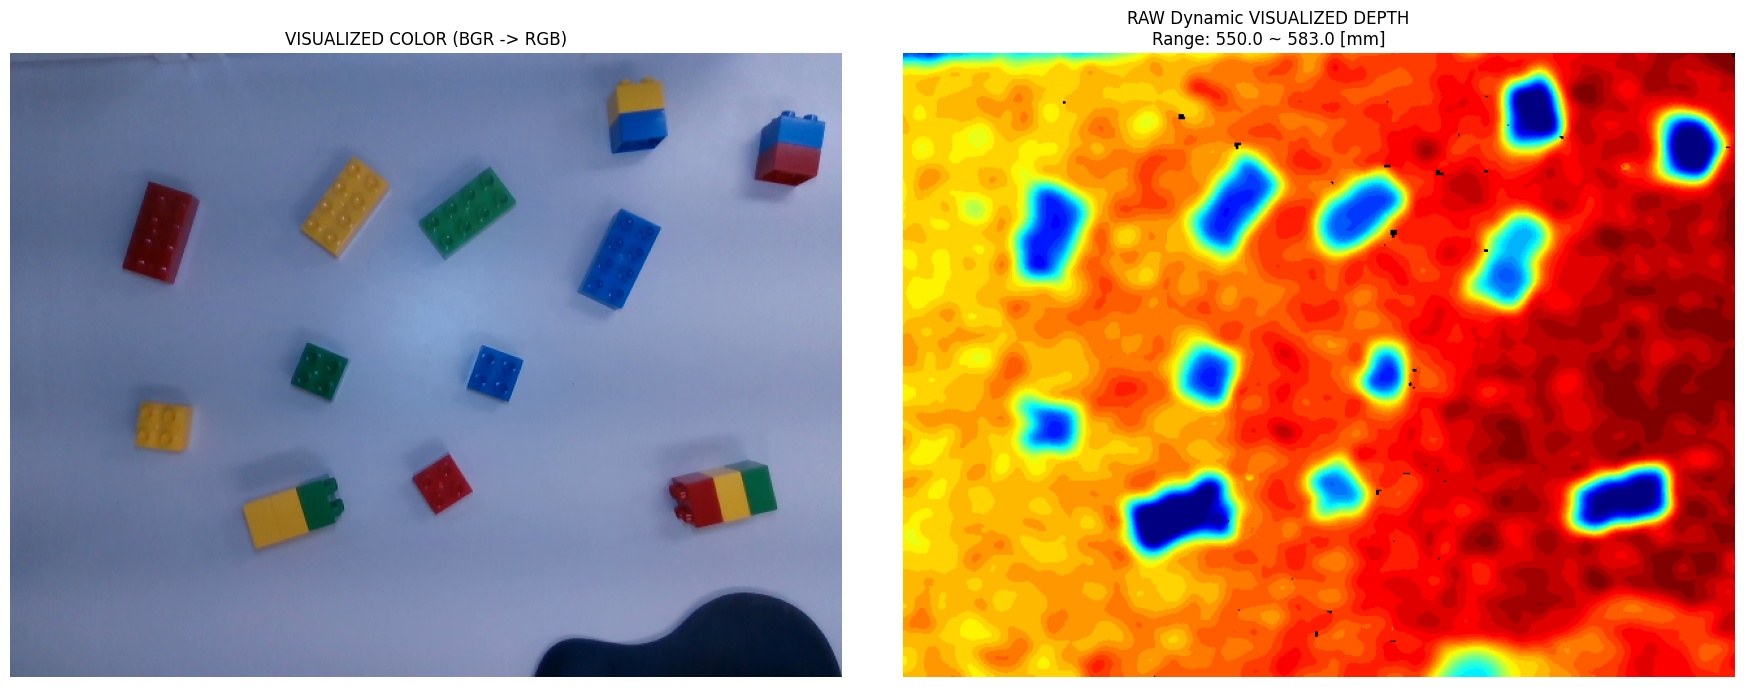

In [ ]:
# 글로벌 변수 - 카메라 원본 이미지
    # color_img_bgr
    # depth_img

# 글로벌 변수 - 처리 완료된 각각의 컬러와 뎁스 저장
    # color_filtered
    # depth_filtered



# color_filtered = color_img_bgr.copy()
# color_filtered_before = color_img_bgr.copy()
color_filtered_after = color_img_bgr.copy()

# depth_filtered = depth_eroded.copy()
# depth_filtered_before = depth_eroded.copy()
depth_filtered_after = depth_img.copy()



# 비율에 맞춰서 이미지 비율 계산
width = 18
height = width * (3 / 8)
figsize=(width, height)

# 1행 2열 figsize에 맞춰서 설정
fig, axes = plt.subplots(1, 2, figsize = figsize)

# 컬러
vis_color_img = cv2.cvtColor(color_filtered_after, cv2.COLOR_BGR2RGB)
axes[0].imshow(vis_color_img)
axes[0].set_title("VISUALIZED COLOR (BGR -> RGB)")
axes[0].axis("off")

# 뎁스
vis_depth_img, depth_range = depth_dynamic_colorization(depth_filtered_after)
axes[1].imshow(vis_depth_img)
axes[1].set_title(f"RAW Dynamic VISUALIZED DEPTH \
                  \nRange: {depth_range[0]:.1f} ~ {depth_range[1]:.1f} [mm] \
                  ")
axes[1].axis("off")

# 시각화
plt.tight_layout()
plt.show()

### **[사용 X]인트린직의 신뢰도 판단**

In [ ]:
# import cv2
# import numpy as np


def get_intrinsics_from_dict(intrinsics):
    """
    capture_color_depth_and_save_intrinsics()가 반환한 intrinsics dict에서
    K, dist, depth_scale을 추출한다.

    현재 코드 구조:
    intrinsics["color & depth"]["fx"], ...
    """
    if "color & depth" in intrinsics:
        cam = intrinsics["color & depth"]
    elif "color" in intrinsics:
        cam = intrinsics["color"]
    else:
        raise KeyError("intrinsics 안에 'color & depth' 또는 'color' 키가 없습니다.")

    fx = float(cam["fx"])
    fy = float(cam["fy"])
    cx = float(cam["cx"])
    cy = float(cam["cy"])

    K = np.array([
        [fx, 0.0, cx],
        [0.0, fy, cy],
        [0.0, 0.0, 1.0]
    ], dtype=np.float64)

    coeffs = cam.get("coeffs", [0, 0, 0, 0, 0])
    dist = np.array(coeffs, dtype=np.float64).reshape(-1, 1)

    depth_scale = float(cam.get("depth_scale", 0.001))

    return K, dist, depth_scale


def make_checkerboard_object_points(pattern_size=(8, 6), square_size_mm=30.0):
    """
    체커보드 내부 코너의 실제 3D 좌표 생성.
    pattern_size = (가로 내부 코너 수, 세로 내부 코너 수)
    예: findChessboardCorners(gray, (8, 6))이면 pattern_size=(8,6)
    """
    cols, rows = pattern_size

    objp = np.zeros((rows * cols, 3), np.float32)
    objp[:, :2] = np.mgrid[0:cols, 0:rows].T.reshape(-1, 2)
    objp *= float(square_size_mm)

    return objp.astype(np.float64)


def detect_checkerboard_corners(
    color_img_bgr,
    pattern_size=(8, 6),
    subpix_window=(5, 5),
    show=False
):
    """
    BGR 이미지에서 체커보드 내부 코너 검출.
    반환:
      success, corners, debug_img
    """
    gray = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2GRAY)

    flags = (
        cv2.CALIB_CB_ADAPTIVE_THRESH
        | cv2.CALIB_CB_NORMALIZE_IMAGE
        | cv2.CALIB_CB_FAST_CHECK
    )

    success, corners = cv2.findChessboardCorners(gray, pattern_size, flags)

    debug_img = color_img_bgr.copy()

    if not success:
        return False, None, debug_img

    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        30,
        0.001
    )

    corners_refined = cv2.cornerSubPix(
        gray,
        corners,
        subpix_window,
        (-1, -1),
        criteria
    )

    cv2.drawChessboardCorners(debug_img, pattern_size, corners_refined, success)

    if show:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        plt.title("Detected Checkerboard Corners")
        plt.axis("off")
        plt.show()

    return True, corners_refined, debug_img


def compute_sdk_reprojection_error(
    color_img_bgr,
    intrinsics,
    pattern_size=(8, 6),
    square_size_mm=30.0,
    show=False
):
    """
    SDK intrinsics를 사용해서 체커보드 reprojection error를 계산한다.

    과정:
    1. 체커보드 코너 검출
    2. SDK K, dist 사용
    3. solvePnP로 체커보드 pose 추정
    4. projectPoints로 다시 투영
    5. 검출 코너와 투영 코너의 픽셀 오차 계산

    반환:
      report, debug_img
    """
    K, dist, _ = get_intrinsics_from_dict(intrinsics)

    success, corners, debug_img = detect_checkerboard_corners(
        color_img_bgr,
        pattern_size=pattern_size,
        show=False
    )

    if not success:
        return {
            "success": False,
            "reason": "checkerboard_not_found"
        }, debug_img

    objp = make_checkerboard_object_points(
        pattern_size=pattern_size,
        square_size_mm=square_size_mm
    )

    image_points = corners.reshape(-1, 2).astype(np.float64)

    ok, rvec, tvec = cv2.solvePnP(
        objp,
        image_points,
        K,
        dist,
        flags=cv2.SOLVEPNP_ITERATIVE
    )

    if not ok:
        return {
            "success": False,
            "reason": "solvePnP_failed"
        }, debug_img

    projected, _ = cv2.projectPoints(objp, rvec, tvec, K, dist)
    projected = projected.reshape(-1, 2)

    errors = np.linalg.norm(image_points - projected, axis=1)

    mean_error = float(np.mean(errors))
    rms_error = float(np.sqrt(np.mean(errors ** 2)))
    max_error = float(np.max(errors))
    std_error = float(np.std(errors))

    # debug draw
    for p_det, p_proj in zip(image_points, projected):
        p_det = tuple(np.round(p_det).astype(int))
        p_proj = tuple(np.round(p_proj).astype(int))

        cv2.circle(debug_img, p_det, 4, (0, 255, 0), -1)      # detected: green
        cv2.circle(debug_img, p_proj, 3, (0, 0, 255), -1)     # projected: red
        cv2.line(debug_img, p_det, p_proj, (255, 0, 0), 1)

    if show:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        plt.title(f"SDK Reprojection RMS: {rms_error:.3f} px")
        plt.axis("off")
        plt.show()

    report = {
        "success": True,
        "mode": "sdk_intrinsics_reprojection_check",
        "num_corners": int(len(image_points)),
        "mean_error_px": mean_error,
        "rms_error_px": rms_error,
        "std_error_px": std_error,
        "max_error_px": max_error,
        "rvec": rvec.flatten().tolist(),
        "tvec_mm": tvec.flatten().tolist(),
        "K": K.tolist(),
        "dist": dist.flatten().tolist(),
    }

    return report, debug_img


def deproject_pixel_to_point(u, v, z_m, K):
    """
    pinhole 모델 기반 deprojection.
    z_m: meter
    반환: meter 단위 3D point
    """
    fx = K[0, 0]
    fy = K[1, 1]
    cx = K[0, 2]
    cy = K[1, 2]

    x = (u - cx) * z_m / fx
    y = (v - cy) * z_m / fy
    z = z_m

    return np.array([x, y, z], dtype=np.float64)


def compute_checkerboard_depth_plane_rms(
    color_img_bgr,
    depth_img,
    intrinsics,
    pattern_size=(8, 6),
    square_size_mm=30.0,
    sample_stride=4,
    erode_px=5,
    show=False
):
    """
    체커보드 영역의 aligned depth를 3D point cloud로 바꾼 뒤,
    평면 fitting RMS를 mm 단위로 계산한다.

    이 값은 RGB intrinsics보다 depth 품질/평면성 확인에 더 직접적임.
    """
    K, _, depth_scale = get_intrinsics_from_dict(intrinsics)

    success, corners, debug_img = detect_checkerboard_corners(
        color_img_bgr,
        pattern_size=pattern_size,
        show=False
    )

    if not success:
        return {
            "success": False,
            "reason": "checkerboard_not_found"
        }, debug_img

    h, w = depth_img.shape[:2]

    # 체커보드 코너를 감싸는 convex hull mask 생성
    pts = corners.reshape(-1, 2).astype(np.int32)
    hull = cv2.convexHull(pts)

    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillConvexPoly(mask, hull, 255)

    if erode_px > 0:
        kernel = np.ones((erode_px, erode_px), np.uint8)
        mask = cv2.erode(mask, kernel, iterations=1)

    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return {
            "success": False,
            "reason": "empty_checkerboard_mask"
        }, debug_img

    # stride 샘플링
    xs = xs[::sample_stride]
    ys = ys[::sample_stride]

    points = []
    for u, v in zip(xs, ys):
        raw_z = depth_img[v, u]
        if raw_z <= 0:
            continue

        z_m = float(raw_z) * depth_scale
        if z_m <= 0:
            continue

        p = deproject_pixel_to_point(u, v, z_m, K)
        points.append(p)

    if len(points) < 30:
        return {
            "success": False,
            "reason": "not_enough_valid_depth_points",
            "num_points": int(len(points))
        }, debug_img

    points = np.asarray(points, dtype=np.float64)

    # SVD 기반 plane fitting
    centroid = np.mean(points, axis=0)
    centered = points - centroid

    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    normal = vh[-1, :]
    normal = normal / np.linalg.norm(normal)

    # point-to-plane distance
    distances_m = centered @ normal
    distances_mm = distances_m * 1000.0

    rms_mm = float(np.sqrt(np.mean(distances_mm ** 2)))
    mean_abs_mm = float(np.mean(np.abs(distances_mm)))
    max_abs_mm = float(np.max(np.abs(distances_mm)))
    std_mm = float(np.std(distances_mm))

    # debug draw
    overlay = debug_img.copy()
    overlay[mask > 0] = (0.5 * overlay[mask > 0] + 0.5 * np.array([0, 255, 255])).astype(np.uint8)
    debug_img = overlay

    cv2.putText(
        debug_img,
        f"Depth plane RMS: {rms_mm:.2f} mm",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 0, 255),
        2
    )

    if show:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Depth Plane RMS: {rms_mm:.2f} mm")
        plt.axis("off")
        plt.show()

    report = {
        "success": True,
        "mode": "checkerboard_depth_plane_rms",
        "num_points": int(len(points)),
        "rms_mm": rms_mm,
        "mean_abs_mm": mean_abs_mm,
        "std_mm": std_mm,
        "max_abs_mm": max_abs_mm,
        "plane_centroid_m": centroid.tolist(),
        "plane_normal": normal.tolist(),
        "depth_scale": depth_scale,
    }

    return report, debug_img


def check_realsense_calibration_once(
    color_img_bgr,
    depth_img,
    intrinsics,
    pattern_size=(8, 6),
    square_size_mm=30.0,
    show=True
):
    """
    한 장의 color/depth/intrinsics로 실행하는 종합 검증 함수.

    반환:
      result = {
        "reprojection": ...,
        "depth_plane": ...,
        "judgement": ...
      }
    """
    reproj_report, reproj_debug = compute_sdk_reprojection_error(
        color_img_bgr=color_img_bgr,
        intrinsics=intrinsics,
        pattern_size=pattern_size,
        square_size_mm=square_size_mm,
        show=show
    )

    plane_report, plane_debug = compute_checkerboard_depth_plane_rms(
        color_img_bgr=color_img_bgr,
        depth_img=depth_img,
        intrinsics=intrinsics,
        pattern_size=pattern_size,
        square_size_mm=square_size_mm,
        show=show
    )

    judgement = {
        "rgb_intrinsics_status": "unknown",
        "depth_plane_status": "unknown",
        "notes": []
    }

    if reproj_report.get("success", False):
        rms_px = reproj_report["rms_error_px"]

        if rms_px < 0.5:
            judgement["rgb_intrinsics_status"] = "good"
        elif rms_px < 1.0:
            judgement["rgb_intrinsics_status"] = "warning"
        else:
            judgement["rgb_intrinsics_status"] = "bad"

        judgement["notes"].append(
            f"SDK intrinsics reprojection RMS = {rms_px:.3f} px"
        )
    else:
        judgement["notes"].append(
            f"Reprojection check failed: {reproj_report.get('reason')}"
        )

    if plane_report.get("success", False):
        rms_mm = plane_report["rms_mm"]

        if rms_mm < 2.0:
            judgement["depth_plane_status"] = "good"
        elif rms_mm < 5.0:
            judgement["depth_plane_status"] = "warning"
        else:
            judgement["depth_plane_status"] = "bad"

        judgement["notes"].append(
            f"Depth plane RMS = {rms_mm:.3f} mm"
        )
    else:
        judgement["notes"].append(
            f"Depth plane check failed: {plane_report.get('reason')}"
        )

    result = {
        "reprojection": reproj_report,
        "depth_plane": plane_report,
        "judgement": judgement,
        "debug_images": {
            "reprojection": reproj_debug,
            "depth_plane": plane_debug,
        }
    }

    return result

In [ ]:
# result = check_realsense_calibration_once(
#     color_img_bgr=color_img_bgr,
#     depth_img=depth_img,
#     intrinsics=intrinsics,
#     pattern_size=(7, 5),
#     square_size_mm=30.0,
#     show=True
# )

# result["judgement"]

### **IMAGE LOAD**

In [ ]:
# # ------------------------------------------------------------
# # 1. 이미 로드된 변수가 없거나 None이면 파일에서 로드
# # ------------------------------------------------------------
# if "depth_img" not in globals() or depth_img is None:
#     depth_img = cv2.imread(
#         "output/realsense_depth_filtered_aligned.png",
#         cv2.IMREAD_UNCHANGED
#     )

# if "color_img_bgr" not in globals() or color_img_bgr is None:
#     color_img_bgr = cv2.imread(
#         "output/realsense_color.png",
#         cv2.IMREAD_COLOR
#     )

# if depth_img is None:
#     raise FileNotFoundError("depth image를 읽지 못했습니다.")

# if color_img_bgr is None:
#     raise FileNotFoundError("color image를 읽지 못했습니다.")

# # ------------------------------------------------------------
# # 2. depth는 2D로 정리
# # ------------------------------------------------------------
# if depth_img.ndim == 3 and depth_img.shape[2] == 1:
#     depth_img = depth_img[:, :, 0]

# if depth_img.ndim != 2:
#     raise ValueError(f"depth_img는 2D depth 이미지여야 합니다. 현재 shape: {depth_img.shape}")

# # ------------------------------------------------------------
# # 4. color는 3채널 유지
# # ------------------------------------------------------------
# if color_img_bgr.ndim != 3 or color_img_bgr.shape[2] != 3:
#     raise ValueError(f"color_img_bgr는 HxWx3 컬러 이미지여야 합니다. 현재 shape: {color_img_bgr.shape}")

# # ------------------------------------------------------------
# # 5. 정보 출력
# # ------------------------------------------------------------
# print("depth:", type(depth_img), depth_img.shape, depth_img.dtype, depth_img.min(), depth_img.max())
# print("color:", type(color_img_bgr), color_img_bgr.shape, color_img_bgr.dtype, color_img_bgr.min(), color_img_bgr.max())

depth: <class 'numpy.ndarray'> (480, 640) uint16 0 645
color: <class 'numpy.ndarray'> (480, 640, 3) uint8 0 255


In [ ]:
# VISUALIZE_COLOR_AND_DEPTH(color_img_bgr, depth_img)

<hr style="height: 10px; background-color: #39FF14; border: none;">

# **전처리 시작**
<hr style="height: 5px; background-color: #39FF14; border: none;">

In [23]:
### 시각화 대비용 함수
def compare_depth(color_filtered, depth_filtered_before, depth_filtered_after):
    # 글로벌 변수 - 카메라 원본 이미지
        # color_img_bgr
        # depth_img

    # 글로벌 변수 - 처리 완료된 각각의 컬러와 뎁스 저장
        # color_filtered
        # depth_filtered

    # 비율에 맞춰서 이미지 비율 계산
    width = 18
    height = width * (3 / 8)
    figsize=(width, height)

    # 1행 2열 figsize에 맞춰서 설정
    fig, axes = plt.subplots(1, 3, figsize = figsize)

    # 컬러
    vis_color_img = cv2.cvtColor(color_filtered, cv2.COLOR_BGR2RGB)
    axes[0].imshow(vis_color_img)
    axes[0].set_title("VISUALIZED COLOR (BGR -> RGB)")
    axes[0].axis("off")

    # 뎁스 비포
    vis_depth_img, depth_range = depth_dynamic_colorization(depth_filtered_before)
    axes[1].imshow(vis_depth_img)
    axes[1].set_title(f"Dynamic VISUALIZED DEPTH [before]\
                    \nRange: {depth_range[0]:.1f} ~ {depth_range[1]:.1f} [mm] \
                    ")
    axes[1].axis("off")

    # 뎁스 애프터
    vis_depth_img, depth_range = depth_dynamic_colorization(depth_filtered_after)
    axes[2].imshow(vis_depth_img)
    axes[2].set_title(f"Dynamic VISUALIZED DEPTH [after]\
                    \nRange: {depth_range[0]:.1f} ~ {depth_range[1]:.1f} [mm] \
                    ")
    axes[2].axis("off")

    # 시각화
    plt.tight_layout()
    plt.show()

def compare_color(color_filtered_before, color_filtered_after, depth_filtered):
    # 글로벌 변수 - 카메라 원본 이미지
        # color_img_bgr
        # depth_img

    # 글로벌 변수 - 처리 완료된 각각의 컬러와 뎁스 저장
        # color_filtered
        # depth_filtered

    # # 비율에 맞춰서 이미지 비율 계산
    # width = 18
    # height = width * (3 / 8)
    # figsize=(width, height)

    # 1행 2열 figsize에 맞춰서 설정
    fig, axes = plt.subplots(1, 3, figsize = figsize)

    # 컬러
    vis_color_img = cv2.cvtColor(color_filtered_before, cv2.COLOR_BGR2RGB)
    axes[0].imshow(vis_color_img)
    axes[0].set_title("VISUALIZED COLOR (BGR -> RGB)")
    axes[0].axis("off")

    # 컬러
    vis_color_img = cv2.cvtColor(color_filtered_after, cv2.COLOR_BGR2RGB)
    axes[1].imshow(vis_color_img)
    axes[1].set_title("VISUALIZED COLOR (BGR -> RGB)")
    axes[1].axis("off")

    # 뎁스 애프터
    vis_depth_img, depth_range = depth_dynamic_colorization(depth_filtered)
    axes[2].imshow(vis_depth_img)
    axes[2].set_title(f"Dynamic VISUALIZED DEPTH \
                    \nRange: {depth_range[0]:.1f} ~ {depth_range[1]:.1f} [mm] \
                    ")
    axes[2].axis("off")

    # 시각화
    plt.tight_layout()
    plt.show()

## **INVALID EROSION**

In [32]:
def apply_valid_mask_erosion(
    depth_img,
    valid_mask=None,
    erosion_kernel=3,
    iterations=1,
    apply_to_depth=True,
    show=False,
    title="Invalid Erosion Depth"
):
    """
    depth image의 valid mask를 erosion하여 invalid 주변부를 제거한다.

    Parameters
    ----------
    depth_img : np.ndarray
        입력 depth image.

    valid_mask : np.ndarray or None
        valid depth mask. None이면 depth_img > 0 기준.

    erosion_kernel : int
        erosion kernel size. 3, 5 권장.

    iterations : int
        erosion 반복 횟수.

    apply_to_depth : bool
        True이면 erosion된 valid mask를 depth에 적용하여 invalid 주변 depth를 0으로 만든다.
        False이면 eroded valid mask만 반환한다.

    show : bool
        전후 이미지 2개만 시각화.

    Returns
    -------
    depth_eroded : np.ndarray
        erosion mask가 적용된 depth image.

    eroded_valid_mask : np.ndarray
        erosion된 valid mask. 값은 0 또는 1.

    info : dict
        처리 정보.
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if not isinstance(depth_img, np.ndarray):
        raise TypeError("depth_img는 np.ndarray 형식이어야 합니다.")

    if depth_img.ndim != 2:
        raise ValueError(f"depth_img는 2D depth 이미지여야 합니다. 현재 shape: {depth_img.shape}")

    if erosion_kernel is None or erosion_kernel <= 0:
        raise ValueError("erosion_kernel은 1 이상의 정수여야 합니다.")

    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        if valid_mask.shape != depth_img.shape:
            raise ValueError("valid_mask와 depth_img의 shape가 다릅니다.")
        valid_bool = (valid_mask > 0) & (depth_img > 0)

    valid_u8 = valid_bool.astype(np.uint8)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (erosion_kernel, erosion_kernel)
    )

    eroded_valid_mask = cv2.erode(
        valid_u8,
        kernel,
        iterations=iterations
    )

    if apply_to_depth:
        depth_eroded = depth_img.copy()
        depth_eroded[eroded_valid_mask == 0] = 0
    else:
        depth_eroded = depth_img.copy()

    info = {
        "filter": "valid_mask_erosion",
        "erosion_kernel": int(erosion_kernel),
        "iterations": int(iterations),
        "apply_to_depth": bool(apply_to_depth),
        "valid_pixels_before": int(np.count_nonzero(valid_u8)),
        "valid_pixels_after": int(np.count_nonzero(eroded_valid_mask)),
        "removed_pixels": int(np.count_nonzero(valid_u8) - np.count_nonzero(eroded_valid_mask)),
    }

    return depth_eroded, eroded_valid_mask, info

In [ ]:
# 원본 카메라
# color_filtered = color_img_bgr.copy()
# depth_filtered = depth_img.copy()

# 이전 필터 비교 전으로 이동
# color_filtered_before = color_filtered_after
depth_filtered_before = depth_filtered_after

valid_mask = (depth_filtered_before > 0).astype(np.uint8)

depth_eroded, valid_mask_eroded, erosion_info = apply_valid_mask_erosion(
    depth_img=depth_filtered_before,
    valid_mask=valid_mask,
    erosion_kernel=5,
    iterations=1,
    apply_to_depth=True,
    show=False,
    title="Invalid Erosion Applied Depth"
)

print("\n[Invalid Erosion 결과 통계]")
pprint.pprint(erosion_info, sort_dicts=False)

NameError: name 'color_filtered_after' is not defined


[INFO] depth_filtered = depth_eroded 으로 갱신되었습니다.
[INFO] valid_mask_filtered = valid_mask_eroded 으로 갱신되었습니다.


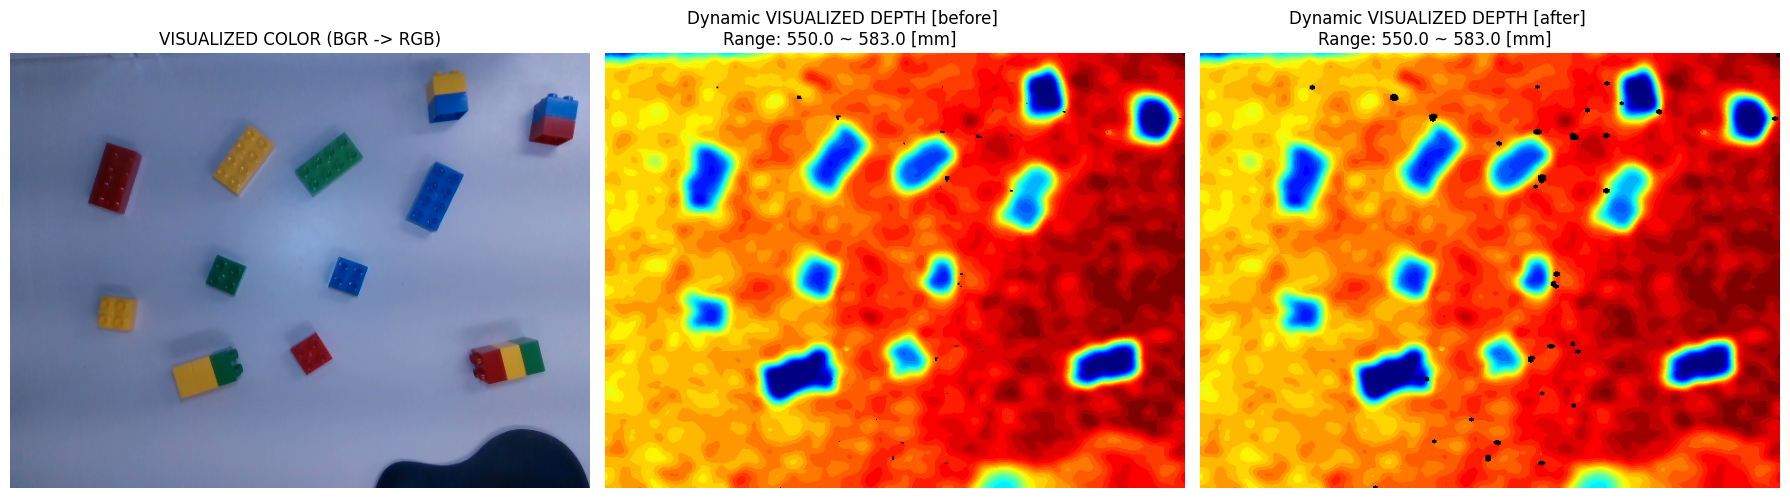

In [ ]:
## eroded 처리 뎁스만 진행

# color_filtered_before = color_img_bgr.copy()
# color_filtered_after = color_img_bgr.copy()

depth_filtered_before = depth_eroded.copy()
depth_filtered_after = depth_eroded.copy()

valid_mask_filtered = valid_mask_eroded.copy()
print("\n[INFO] depth_filtered = depth_eroded 으로 갱신되었습니다.")
print("[INFO] valid_mask_filtered = valid_mask_eroded 으로 갱신되었습니다.")



# color_filtered_after = 
depth_filtered_after = depth_eroded
valid_mask_filtered = valid_mask_eroded.copy()




compare_depth(
    color_filtered=color_filtered_after,
    depth_filtered_before=depth_img,
    depth_filtered_after=depth_filtered
)

---

## **MEDIAN**

In [31]:
def apply_depth_median_filter(
    depth_img,
    ksize=5,
    valid_mask=None,
    fill_holes=True,
    restore_invalid=True,
    hole_fill_ksize=3,
    show=False,
    title="Depth Median Filter"
):
    """
    depth 이미지에 median filter를 적용한다.

    목적
    ----
    RealSense depth에서 튀는 점과 salt-pepper 형태의 노이즈를 줄인다.
    단, invalid depth=0 때문에 median filter가 객체 경계를 파먹는 문제를 줄이기 위해
    선택적으로 invalid 영역을 주변 valid median 값으로 임시 보정한 뒤 median filter를 수행한다.

    Parameters
    ----------
    depth_img : np.ndarray
        입력 depth image. 보통 RealSense uint16 depth image.

    ksize : int
        median filter kernel size. 3 이상의 홀수.

    valid_mask : np.ndarray or None
        유효 depth mask. 1 또는 255 = valid.
        None이면 depth_img > 0 기준으로 생성.

    fill_holes : bool
        True이면 median filter 전에 invalid=0 영역을 주변 valid median 값으로 임시 보정한다.
        이는 0값 때문에 median filter가 경계를 파먹는 현상을 줄이기 위한 목적이다.

    restore_invalid : bool
        True이면 원래 invalid였던 픽셀은 최종 결과에서도 0으로 되돌린다.
        RANSAC, point cloud, gradient 계산용이면 True 권장.
        단순 시각화용이면 False도 가능.

    hole_fill_ksize : int
        invalid 임시 보정에 사용할 주변 kernel size. 3, 5 정도 권장.

    show : bool
        True이면 원본, 필터 결과, 차이 이미지를 시각화한다.

    title : str
        시각화 제목.

    Returns
    -------
    depth_filtered : np.ndarray
        median filter가 적용된 depth image.

    filter_info : dict
        필터 적용 정보와 통계.
    """

    # ---------------------------------------------------------
    # 0. 입력 검사
    # ---------------------------------------------------------
    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if not isinstance(depth_img, np.ndarray):
        raise TypeError("depth_img는 np.ndarray 형식이어야 합니다.")

    if depth_img.ndim != 2:
        raise ValueError(
            f"depth_img는 2D depth 이미지여야 합니다. 현재 shape: {depth_img.shape}"
        )

    if ksize % 2 == 0 or ksize < 3:
        raise ValueError("ksize는 최소 3 이상의 홀수여야 합니다. 예: 3, 5, 7")

    if hole_fill_ksize % 2 == 0 or hole_fill_ksize < 3:
        raise ValueError("hole_fill_ksize는 최소 3 이상의 홀수여야 합니다. 예: 3, 5")

    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        if valid_mask.shape != depth_img.shape:
            raise ValueError("valid_mask와 depth_img의 shape가 다릅니다.")
        valid_bool = (valid_mask > 0) & (depth_img > 0)

    original_invalid_bool = ~valid_bool

    # ---------------------------------------------------------
    # 1. median filter 전 invalid=0 임시 보정
    # ---------------------------------------------------------
    depth_to_filter = depth_img.copy()

    filled_pixel_count = 0

    if fill_holes:
        # invalid 영역만 주변 median 값으로 임시 보정
        # cv2.medianBlur는 0까지 포함해서 median을 내므로,
        # 0이 경계를 파먹는 문제를 줄이기 위해 valid 값 기반으로 보정한다.

        depth_float = depth_img.astype(np.float32)

        # invalid 영역은 임시로 큰 값이 아니라 주변 연산을 위해 0 유지
        # 주변 valid median을 직접 계산하는 방식
        pad = hole_fill_ksize // 2
        padded_depth = np.pad(
            depth_float,
            pad_width=pad,
            mode="edge"
        )
        padded_valid = np.pad(
            valid_bool.astype(np.uint8),
            pad_width=pad,
            mode="constant",
            constant_values=0
        )

        filled_depth = depth_float.copy()

        invalid_y, invalid_x = np.where(~valid_bool)

        for y, x in zip(invalid_y, invalid_x):
            y0 = y
            x0 = x

            local_depth = padded_depth[
                y0:y0 + hole_fill_ksize,
                x0:x0 + hole_fill_ksize
            ]
            local_valid = padded_valid[
                y0:y0 + hole_fill_ksize,
                x0:x0 + hole_fill_ksize
            ] > 0

            local_values = local_depth[local_valid]

            if local_values.size > 0:
                filled_depth[y, x] = np.median(local_values)
                filled_pixel_count += 1

        if np.issubdtype(depth_img.dtype, np.integer):
            depth_to_filter = np.clip(
                filled_depth,
                0,
                np.iinfo(depth_img.dtype).max
            ).astype(depth_img.dtype)
        else:
            depth_to_filter = filled_depth.astype(depth_img.dtype)

    # ---------------------------------------------------------
    # 2. Median Filtering
    # ---------------------------------------------------------
    depth_filtered = cv2.medianBlur(depth_to_filter, ksize)

    # ---------------------------------------------------------
    # 3. 원래 invalid 영역 복원
    # ---------------------------------------------------------
    if restore_invalid:
        depth_filtered[original_invalid_bool] = 0

    # ---------------------------------------------------------
    # 4. 통계 정보 계산
    # ---------------------------------------------------------
    valid_before = depth_img[valid_bool]
    valid_after = depth_filtered[valid_bool]

    before_median = float(np.median(valid_before)) if valid_before.size > 0 else None
    before_mean = float(np.mean(valid_before)) if valid_before.size > 0 else None
    before_std = float(np.std(valid_before)) if valid_before.size > 0 else None

    after_median = float(np.median(valid_after)) if valid_after.size > 0 else None
    after_mean = float(np.mean(valid_after)) if valid_after.size > 0 else None
    after_std = float(np.std(valid_after)) if valid_after.size > 0 else None

    valid_after_bool = depth_filtered > 0

    diff = cv2.absdiff(depth_img, depth_filtered)
    diff_valid = diff[valid_bool]

    diff_mean = float(np.mean(diff_valid)) if diff_valid.size > 0 else None
    diff_median = float(np.median(diff_valid)) if diff_valid.size > 0 else None
    diff_max = float(np.max(diff_valid)) if diff_valid.size > 0 else None

    filter_info = {
        "filter": "median",
        "ksize": int(ksize),
        "fill_holes": bool(fill_holes),
        "restore_invalid": bool(restore_invalid),
        "hole_fill_ksize": int(hole_fill_ksize),
        "filled_pixel_count": int(filled_pixel_count),

        "valid_pixels_before": int(np.count_nonzero(valid_bool)),
        "valid_pixels_after": int(np.count_nonzero(valid_after_bool)),
        "zero_pixels_before": int(np.count_nonzero(depth_img == 0)),
        "zero_pixels_after": int(np.count_nonzero(depth_filtered == 0)),

        "before_median_raw": before_median,
        "before_mean_raw": before_mean,
        "before_std_raw": before_std,

        "after_median_raw": after_median,
        "after_mean_raw": after_mean,
        "after_std_raw": after_std,

        "diff_mean_raw": diff_mean,
        "diff_median_raw": diff_median,
        "diff_max_raw": diff_max,
    }

    # ---------------------------------------------------------
    # 5. 시각화
    # ---------------------------------------------------------
    if show:
        print("[DEPTH MEDIAN FILTER]")
        print(f"ksize           : {ksize}")
        print(f"fill_holes      : {fill_holes}")
        print(f"restore_invalid : {restore_invalid}")
        print(f"hole_fill_ksize : {hole_fill_ksize}")
        print(f"filled pixels   : {filled_pixel_count}")

        raw_colormap = cv2.applyColorMap(
            cv2.convertScaleAbs(depth_img, alpha=0.03),
            cv2.COLORMAP_JET
        )

        filtered_colormap = cv2.applyColorMap(
            cv2.convertScaleAbs(depth_filtered, alpha=0.03),
            cv2.COLORMAP_JET
        )

        raw_rgb = cv2.cvtColor(raw_colormap, cv2.COLOR_BGR2RGB)
        filtered_rgb = cv2.cvtColor(filtered_colormap, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(raw_rgb)
        axes[0].set_title("Input Depth")
        axes[0].axis("off")

        axes[1].imshow(filtered_rgb)
        axes[1].set_title(title)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return depth_filtered, filter_info

In [233]:
valid_mask = (depth_img > 0).astype(np.uint8)
# valid_mask = (depth_img > 0) & (depth_img < 1200)

depth_median, depth_filter_median_info = apply_depth_median_filter(
    depth_img=depth_img,
    ksize=3,
    valid_mask=valid_mask,

    # invalid=0 때문에 median filter가 엣지를 파먹는 문제 완화
    fill_holes=True,

    # 실제 RANSAC / point cloud / gradient 계산용이면 True 권장
    restore_invalid=True,

    # invalid 임시 보정용 주변 kernel
    hole_fill_ksize=3,

    show=False,
    title="Median Filtered Depth"
)

# print("\n[Median 필터 적용 결과 통계]")
# pprint.pprint(depth_filter_median_info, sort_dicts=False)

---

In [ ]:
# VISUALIZE_COLOR_AND_DEPTH(color_img_bgr, depth_filtered)

# BGR -> RGB 변환 필요
vis_color_img = cv2.cvtColor(color_img_bgr, cv2.COLOR_BGR2RGB)

# 뎁스 시각화
vis_depth_img = cv2.applyColorMap(
    cv2.convertScaleAbs(depth_filtered, alpha=0.025),
    cv2.COLORMAP_JET
)

# 설정 -------------------------------------------

# 비율에 맞춰서 이미지 비율 계산
width = 18
height = width * (3 / 8)
figsize=(width, height)

# 1행 2열 figsize에 맞춰서 설정
fig, axes = plt.subplots(1, 2, figsize = figsize)

# 컬러
axes[0].imshow(vis_color_img)
axes[0].set_title("VISUALIZED COLOR (BGR -> RGB)")
axes[0].axis("off")

# 뎁스
axes[1].imshow(vis_depth_img)
axes[1].set_title("VISUALIZED DEPTH (ColorMap Applied)")
axes[1].axis("off")

# 시각화
plt.tight_layout()
plt.show()

# **RANSAC**

RANSAC_intro.png

In [ ]:
def estimate_ransac_plane_from_depth(
    depth_img,
    intrinsics,
    valid_mask=None,
    depth_scale=None,
    stride=2,
    min_depth_m=0.15,
    max_depth_m=1.20,
    distance_threshold=0.01,
    ransac_n=3,
    num_iterations=1000,
    show=False,
    title="RANSAC Plane"
):
    """
    depth image에서 point cloud를 만들고 RANSAC으로 가장 큰 평면을 추정한다.

    Returns
    -------
    plane_model : list
        [a, b, c, d], ax + by + cz + d = 0

    plane_info : dict
        RANSAC 결과 정보

    plane_mask : np.ndarray
        RANSAC 평면 inlier mask, uint8 0/255
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if depth_img.ndim != 2:
        raise ValueError("depth_img는 2D depth 이미지여야 합니다.")

    h, w = depth_img.shape

    # ------------------------------------------------------------
    # 1. intrinsics 읽기
    # ------------------------------------------------------------
    if "color" in intrinsics:
        intr = intrinsics["color"]
    else:
        intr = intrinsics

    fx = float(intr["fx"])
    fy = float(intr["fy"])
    cx = float(intr["cx"])
    cy = float(intr["cy"])

    if depth_scale is None:
        if "depth" in intrinsics and "depth_scale" in intrinsics["depth"]:
            depth_scale = float(intrinsics["depth"]["depth_scale"])
        else:
            depth_scale = 0.001

    # ------------------------------------------------------------
    # 2. valid depth mask
    # ------------------------------------------------------------
    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        if valid_mask.shape != depth_img.shape:
            raise ValueError("valid_mask와 depth_img의 shape가 다릅니다.")
        valid_bool = (valid_mask > 0) & (depth_img > 0)

    depth_m = depth_img.astype(np.float32) * float(depth_scale)

    valid_bool &= depth_m >= min_depth_m
    valid_bool &= depth_m <= max_depth_m

    ys, xs = np.where(valid_bool)

    if stride is not None and stride > 1:
        keep = ((xs % stride) == 0) & ((ys % stride) == 0)
        xs = xs[keep]
        ys = ys[keep]

    if xs.size < ransac_n:
        raise ValueError("RANSAC에 사용할 point 수가 너무 적습니다.")

    # ------------------------------------------------------------
    # 3. depth pixel → 3D point
    # ------------------------------------------------------------
    z = depth_m[ys, xs]
    x = (xs.astype(np.float32) - cx) * z / fx
    y = (ys.astype(np.float32) - cy) * z / fy

    points = np.stack([x, y, z], axis=1).astype(np.float64)

    # ------------------------------------------------------------
    # 4. RANSAC plane fitting
    # ------------------------------------------------------------
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)

    plane_model, inliers = pcd.segment_plane(
        distance_threshold=distance_threshold,
        ransac_n=ransac_n,
        num_iterations=num_iterations
    )

    inliers = np.array(inliers, dtype=np.int64)

    # normal 정규화
    a, b, c, d = [float(v) for v in plane_model]
    norm = np.sqrt(a * a + b * b + c * c)

    a, b, c, d = a / norm, b / norm, c / norm, d / norm
    plane_model = [a, b, c, d]

    # ------------------------------------------------------------
    # 5. inlier mask 생성
    # ------------------------------------------------------------
    plane_mask = np.zeros_like(depth_img, dtype=np.uint8)

    inlier_xs = xs[inliers]
    inlier_ys = ys[inliers]

    plane_mask[inlier_ys, inlier_xs] = 255

    if stride is not None and stride > 1:
        k = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (stride * 2 + 1, stride * 2 + 1)
        )
        plane_mask = cv2.dilate(plane_mask, k, iterations=1)

    inlier_ratio = len(inliers) / max(points.shape[0], 1)

    plane_info = {
        "plane_model": plane_model,
        "point_count": int(points.shape[0]),
        "inlier_count": int(len(inliers)),
        "inlier_ratio": float(inlier_ratio),
        "distance_threshold_m": float(distance_threshold),
        "stride": int(stride),
        "min_depth_m": float(min_depth_m),
        "max_depth_m": float(max_depth_m),
    }

    # ------------------------------------------------------------
    # 6. 시각화
    # ------------------------------------------------------------
    if show:
        print("[RANSAC PLANE ESTIMATION]")
        print(f"plane model  : {plane_model}")
        print(f"point count  : {points.shape[0]}")
        print(f"inliers      : {len(inliers)}")
        print(f"inlier ratio : {inlier_ratio:.3f}")

        depth_vis = cv2.applyColorMap(
            cv2.convertScaleAbs(depth_img, alpha=0.03),
            cv2.COLORMAP_JET
        )
        depth_vis = cv2.cvtColor(depth_vis, cv2.COLOR_BGR2RGB)

        overlay = depth_vis.copy()
        red = np.zeros_like(overlay)
        red[:, :, 0] = 255

        mask_bool = plane_mask > 0
        overlay[mask_bool] = (
            0.55 * overlay[mask_bool] + 0.45 * red[mask_bool]
        ).astype(np.uint8)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(depth_vis)
        axes[0].set_title("Input Depth")
        axes[0].axis("off")

        axes[1].imshow(overlay)
        axes[1].set_title(title)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return plane_model, plane_info, plane_mask

In [ ]:
plane_model, plane_info, plane_mask = estimate_ransac_plane_from_depth(
    depth_img=depth_filtered,
    intrinsics=intrinsics,
    valid_mask=valid_mask_filtered,
    stride=2,
    min_depth_m=0.15,
    max_depth_m=1.20,
    distance_threshold=0.01,
    ransac_n=3,
    num_iterations=1000,
    show=True,
    title="RANSAC Plane Inliers"
)

print("\n[RANSAC 평면 추정 결과]")
pprint.pprint(plane_info, sort_dicts=False)

# **평면 신뢰도 검사**

In [ ]:
def check_ransac_plane_reliability(
    plane_info,
    plane_mask,
    image_shape,
    min_inlier_ratio=0.25,
    min_plane_area_ratio=0.10,
    show=False,
    title="RANSAC Plane Reliability"
):
    """
    RANSAC으로 추정된 평면이 신뢰 가능한지 검사한다.

    검사 기준
    --------
    1. inlier_ratio가 너무 낮지 않은가
    2. plane_mask가 이미지에서 충분한 면적을 차지하는가

    Returns
    -------
    is_reliable : bool
        평면 신뢰 가능 여부

    reliability_info : dict
        검사 결과 정보
    """

    if plane_info is None:
        raise ValueError("plane_info가 None입니다.")

    if plane_mask is None:
        raise ValueError("plane_mask가 None입니다.")

    h, w = image_shape[:2]
    image_area = h * w

    inlier_ratio = float(plane_info.get("inlier_ratio", 0.0))

    plane_pixels = int(np.count_nonzero(plane_mask > 0))
    plane_area_ratio = plane_pixels / max(image_area, 1)

    reasons = []
    is_reliable = True

    if inlier_ratio < min_inlier_ratio:
        is_reliable = False
        reasons.append(
            f"inlier_ratio 낮음: {inlier_ratio:.3f} < {min_inlier_ratio:.3f}"
        )

    if plane_area_ratio < min_plane_area_ratio:
        is_reliable = False
        reasons.append(
            f"plane_area_ratio 낮음: {plane_area_ratio:.3f} < {min_plane_area_ratio:.3f}"
        )

    if len(reasons) == 0:
        reasons.append("RANSAC plane 신뢰 가능")

    reliability_info = {
        "is_reliable": bool(is_reliable),
        "inlier_ratio": float(inlier_ratio),
        "min_inlier_ratio": float(min_inlier_ratio),
        "plane_pixels": int(plane_pixels),
        "plane_area_ratio": float(plane_area_ratio),
        "min_plane_area_ratio": float(min_plane_area_ratio),
        "reasons": reasons,
    }

    if show:
        print("[RANSAC PLANE RELIABILITY]")
        print(f"is reliable       : {is_reliable}")
        print(f"inlier ratio      : {inlier_ratio:.3f}")
        print(f"plane area ratio  : {plane_area_ratio:.3f}")
        print("reasons:")
        for r in reasons:
            print(f"  - {r}")

        plt.figure(figsize=(6, 5))
        plt.imshow(plane_mask, cmap="gray")
        plt.title(title)
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return is_reliable, reliability_info

In [ ]:
is_plane_reliable, plane_reliability_info = check_ransac_plane_reliability(
    plane_info=plane_info,
    plane_mask=plane_mask,
    image_shape=depth_filtered.shape,
    min_inlier_ratio=0.25,
    min_plane_area_ratio=0.10,
    show=True,
    title="RANSAC Plane Reliability"
)

print("\n[RANSAC 평면 신뢰도 검사 결과]")
pprint.pprint(plane_reliability_info, sort_dicts=False)

# **PLANE-RELATIVE HEIGHT MAP**

In [ ]:
def create_plane_relative_height_map(
    depth_img,
    plane_model,
    intrinsics,
    valid_mask=None,
    depth_scale=None,
    min_depth_m=0.15,
    max_depth_m=1.20,
    remove_behind=True,
    behind_margin_m=0.005,
    show=False,
    title="Plane-relative Height Map"
):
    """
    depth image를 RANSAC 평면 기준 height map으로 변환한다.

    height_map 단위는 meter.
    
    height > 0 : 평면보다 카메라 쪽, 즉 바닥 위로 솟은 후보
    height = 0 : RANSAC 평면
    height < 0 : 평면 뒤쪽 / 낭떠러지 / 먼 배경 후보
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if depth_img.ndim != 2:
        raise ValueError("depth_img는 2D depth 이미지여야 합니다.")

    h, w = depth_img.shape

    # ------------------------------------------------------------
    # 1. intrinsics 읽기
    # ------------------------------------------------------------
    if "color" in intrinsics:
        intr = intrinsics["color"]
    else:
        intr = intrinsics

    fx = float(intr["fx"])
    fy = float(intr["fy"])
    cx = float(intr["cx"])
    cy = float(intr["cy"])

    if depth_scale is None:
        if "depth" in intrinsics and "depth_scale" in intrinsics["depth"]:
            depth_scale = float(intrinsics["depth"]["depth_scale"])
        else:
            depth_scale = 0.001

    # ------------------------------------------------------------
    # 2. valid mask
    # ------------------------------------------------------------
    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        if valid_mask.shape != depth_img.shape:
            raise ValueError("valid_mask와 depth_img의 shape가 다릅니다.")
        valid_bool = (valid_mask > 0) & (depth_img > 0)

    depth_m = depth_img.astype(np.float32) * float(depth_scale)

    valid_bool &= depth_m >= min_depth_m
    valid_bool &= depth_m <= max_depth_m

    # ------------------------------------------------------------
    # 3. plane model 정규화
    # ------------------------------------------------------------
    a, b, c, d = [float(v) for v in plane_model]

    norm = np.sqrt(a * a + b * b + c * c)
    if norm < 1e-12:
        raise ValueError("plane normal norm이 너무 작습니다.")

    a, b, c, d = a / norm, b / norm, c / norm, d / norm

    # 카메라 원점이 있는 쪽을 positive로 맞춤
    camera_side = np.sign(d)
    if camera_side == 0:
        camera_side = 1.0

    a *= camera_side
    b *= camera_side
    c *= camera_side
    d *= camera_side

    # ------------------------------------------------------------
    # 4. pixel → 3D point → plane height 계산
    # ------------------------------------------------------------
    height_map = np.zeros_like(depth_m, dtype=np.float32)
    height_valid_mask = np.zeros_like(depth_img, dtype=np.uint8)

    ys, xs = np.where(valid_bool)

    if xs.size == 0:
        raise ValueError("height map을 만들 valid depth point가 없습니다.")

    z = depth_m[ys, xs]
    x = (xs.astype(np.float32) - cx) * z / fx
    y = (ys.astype(np.float32) - cy) * z / fy

    plane_height = a * x + b * y + c * z + d

    if remove_behind:
        keep = plane_height >= -behind_margin_m
    else:
        keep = np.ones_like(plane_height, dtype=bool)

    kept_xs = xs[keep]
    kept_ys = ys[keep]
    kept_height = plane_height[keep]

    height_map[kept_ys, kept_xs] = kept_height.astype(np.float32)
    height_valid_mask[kept_ys, kept_xs] = 1

    # ------------------------------------------------------------
    # 5. info
    # ------------------------------------------------------------
    if kept_height.size > 0:
        height_info = {
            "height_min_m": float(np.min(kept_height)),
            "height_max_m": float(np.max(kept_height)),
            "height_p05_m": float(np.percentile(kept_height, 5)),
            "height_p50_m": float(np.percentile(kept_height, 50)),
            "height_p95_m": float(np.percentile(kept_height, 95)),
        }
    else:
        height_info = {
            "height_min_m": None,
            "height_max_m": None,
            "height_p05_m": None,
            "height_p50_m": None,
            "height_p95_m": None,
        }

    info = {
        "filter": "plane_relative_height_map",
        "remove_behind": bool(remove_behind),
        "behind_margin_m": float(behind_margin_m),
        "valid_pixels_before": int(np.count_nonzero(valid_bool)),
        "valid_pixels_after": int(np.count_nonzero(height_valid_mask)),
        "removed_behind_pixels": int(np.count_nonzero(valid_bool) - np.count_nonzero(height_valid_mask)),
        "plane_model_oriented": [float(a), float(b), float(c), float(d)],
        **height_info
    }

    # ------------------------------------------------------------
    # 6. 시각화
    # ------------------------------------------------------------
    if show:
        print("[PLANE-RELATIVE HEIGHT MAP]")
        print(f"valid before    : {info['valid_pixels_before']}")
        print(f"valid after     : {info['valid_pixels_after']}")
        print(f"removed behind  : {info['removed_behind_pixels']}")
        print(f"height p50      : {info['height_p50_m']}")
        print(f"height p95      : {info['height_p95_m']}")

        depth_colormap = cv2.applyColorMap(
            cv2.convertScaleAbs(depth_img, alpha=0.03),
            cv2.COLORMAP_JET
        )
        depth_rgb = cv2.cvtColor(depth_colormap, cv2.COLOR_BGR2RGB)

        height_mm = height_map * 1000.0
        valid_h = height_mm[height_valid_mask > 0]

        height_vis = np.zeros_like(depth_img, dtype=np.uint8)

        if valid_h.size > 0:
            p05 = np.percentile(valid_h, 5)
            p95 = np.percentile(valid_h, 95)

            height_clip = np.clip(height_mm, p05, p95)

            height_vis = cv2.normalize(
                height_clip,
                None,
                0,
                255,
                cv2.NORM_MINMAX
            ).astype(np.uint8)

            height_vis[height_valid_mask == 0] = 0

        height_color = cv2.applyColorMap(height_vis, cv2.COLORMAP_JET)
        height_rgb = cv2.cvtColor(height_color, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(depth_rgb)
        axes[0].set_title("Input Depth")
        axes[0].axis("off")

        axes[1].imshow(height_rgb)
        axes[1].set_title(title)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return height_map, height_valid_mask, info

In [ ]:
height_map, height_valid_mask, height_info = create_plane_relative_height_map(
    depth_img=depth_filtered,
    plane_model=plane_model,
    intrinsics=intrinsics,
    valid_mask=valid_mask_filtered,
    min_depth_m=0.15,
    max_depth_m=1.20,
    remove_behind=True,
    behind_margin_m=0.005,
    show=True,
    title="Plane-relative Height Map"
)

print("\n[Plane-relative Height Map 결과]")
pprint.pprint(height_info, sort_dicts=False)

# **HEIGHT POSITIVE MASK**

In [ ]:
def create_height_positive_mask(
    height_map,
    height_valid_mask=None,
    min_height_mm=4.0,
    max_height_mm=150.0,
    close_kernel=5,
    open_kernel=3,
    min_area=50,
    show=False,
    title="Height Positive Mask"
):
    """
    plane-relative height_map에서 평면보다 일정 높이 이상 솟은 영역을 마스크로 만든다.

    height_map 단위는 meter.
    min_height_mm, max_height_mm 단위는 mm.

    Returns
    -------
    height_mask : np.ndarray
        uint8 binary mask. 0 또는 255.

    mask_info : dict
        마스크 생성 정보.
    """

    if height_map is None:
        raise ValueError("height_map이 None입니다.")

    if not isinstance(height_map, np.ndarray):
        raise TypeError("height_map은 np.ndarray 형식이어야 합니다.")

    if height_map.ndim != 2:
        raise ValueError(f"height_map은 2D여야 합니다. 현재 shape: {height_map.shape}")

    if height_valid_mask is None:
        valid_bool = height_map != 0
    else:
        if height_valid_mask.shape != height_map.shape:
            raise ValueError("height_valid_mask와 height_map의 shape가 다릅니다.")
        valid_bool = height_valid_mask > 0

    height_mm = height_map.astype(np.float32) * 1000.0

    mask_bool = (
        valid_bool &
        (height_mm >= float(min_height_mm)) &
        (height_mm <= float(max_height_mm))
    )

    height_mask = mask_bool.astype(np.uint8) * 255

    if close_kernel is not None and close_kernel > 0:
        k_close = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (close_kernel, close_kernel)
        )
        height_mask = cv2.morphologyEx(height_mask, cv2.MORPH_CLOSE, k_close)

    if open_kernel is not None and open_kernel > 0:
        k_open = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (open_kernel, open_kernel)
        )
        height_mask = cv2.morphologyEx(height_mask, cv2.MORPH_OPEN, k_open)

    # 작은 component 제거
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        height_mask,
        connectivity=8
    )

    cleaned_mask = np.zeros_like(height_mask)
    components = []

    for label_id in range(1, num_labels):
        area = int(stats[label_id, cv2.CC_STAT_AREA])

        if area < min_area:
            continue

        cleaned_mask[labels == label_id] = 255

        components.append({
            "label_id": int(label_id),
            "area": area,
            "bbox": [
                int(stats[label_id, cv2.CC_STAT_LEFT]),
                int(stats[label_id, cv2.CC_STAT_TOP]),
                int(stats[label_id, cv2.CC_STAT_WIDTH]),
                int(stats[label_id, cv2.CC_STAT_HEIGHT]),
            ],
        })

    mask_info = {
        "filter": "height_positive_mask",
        "min_height_mm": float(min_height_mm),
        "max_height_mm": float(max_height_mm),
        "close_kernel": int(close_kernel) if close_kernel else 0,
        "open_kernel": int(open_kernel) if open_kernel else 0,
        "min_area": int(min_area),
        "valid_pixels": int(np.count_nonzero(valid_bool)),
        "mask_pixels_before_area_filter": int(np.count_nonzero(height_mask)),
        "mask_pixels_after_area_filter": int(np.count_nonzero(cleaned_mask)),
        "component_count": len(components),
        "components": components,
    }

    if show:
        print("[HEIGHT POSITIVE MASK]")
        print(f"min height mm : {min_height_mm}")
        print(f"max height mm : {max_height_mm}")
        print(f"mask pixels   : {mask_info['mask_pixels_after_area_filter']}")
        print(f"components    : {len(components)}")

        valid_h = height_mm[valid_bool]

        height_vis = np.zeros_like(height_map, dtype=np.uint8)

        if valid_h.size > 0:
            p05 = np.percentile(valid_h, 5)
            p95 = np.percentile(valid_h, 95)

            height_clip = np.clip(height_mm, p05, p95)
            height_vis = cv2.normalize(
                height_clip,
                None,
                0,
                255,
                cv2.NORM_MINMAX
            ).astype(np.uint8)

            height_vis[~valid_bool] = 0

        height_color = cv2.applyColorMap(height_vis, cv2.COLORMAP_JET)
        height_rgb = cv2.cvtColor(height_color, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(height_rgb)
        axes[0].set_title("Plane-relative Height Map")
        axes[0].axis("off")

        axes[1].imshow(cleaned_mask, cmap="gray")
        axes[1].set_title(title)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return cleaned_mask, mask_info

In [ ]:
height_positive_mask, height_positive_info = create_height_positive_mask(
    height_map=height_map,
    height_valid_mask=height_valid_mask,
    min_height_mm=10.0,
    max_height_mm=150.0,
    close_kernel=5,
    open_kernel=3,
    min_area=50,
    show=True,
    title="Height Positive Mask"
)

print("\n[Height Positive Mask 결과]")
pprint.pprint(height_positive_info, sort_dicts=False)

# **HEIGHT MAP NORMALIZATION**

In [ ]:
def normalize_height_map_to_uint8(
    height_map,
    height_valid_mask=None,
    pmin=1,
    pmax=99,
    positive_only=True,
    show=False,
    title="Normalized Height Map"
):
    """
    plane-relative height_map을 CLAHE / threshold용 uint8 이미지로 정규화한다.

    Parameters
    ----------
    height_map : np.ndarray
        plane-relative height map. 단위 meter.

    height_valid_mask : np.ndarray or None
        valid mask. 1 = valid.

    pmin, pmax : float
        percentile 정규화 범위.

    positive_only : bool
        True이면 height > 0 영역만 정규화에 사용.
        평면보다 카메라 쪽으로 솟은 부분만 강조할 때 사용.

    Returns
    -------
    height_u8 : np.ndarray
        uint8 height image. 0~255.

    norm_info : dict
        정규화 정보.
    """

    if height_map is None:
        raise ValueError("height_map이 None입니다.")

    if not isinstance(height_map, np.ndarray):
        raise TypeError("height_map은 np.ndarray 형식이어야 합니다.")

    if height_map.ndim != 2:
        raise ValueError(f"height_map은 2D여야 합니다. 현재 shape: {height_map.shape}")

    if height_valid_mask is None:
        valid_bool = height_map != 0
    else:
        if height_valid_mask.shape != height_map.shape:
            raise ValueError("height_valid_mask와 height_map의 shape가 다릅니다.")
        valid_bool = height_valid_mask > 0

    if positive_only:
        valid_bool = valid_bool & (height_map > 0)

    height_mm = height_map.astype(np.float32) * 1000.0
    valid_values = height_mm[valid_bool]

    height_u8 = np.zeros_like(height_map, dtype=np.uint8)

    if valid_values.size == 0:
        return height_u8, {
            "filter": "normalize_height_map_to_uint8",
            "error": "No valid height pixels",
            "positive_only": bool(positive_only),
        }

    vmin = float(np.percentile(valid_values, pmin))
    vmax = float(np.percentile(valid_values, pmax))

    if vmax > vmin:
        height_u8[valid_bool] = np.clip(
            (height_mm[valid_bool] - vmin) / (vmax - vmin) * 255.0,
            0,
            255
        ).astype(np.uint8)

    norm_info = {
        "filter": "normalize_height_map_to_uint8",
        "positive_only": bool(positive_only),
        "pmin": float(pmin),
        "pmax": float(pmax),
        "vmin_mm": vmin,
        "vmax_mm": vmax,
        "valid_pixels": int(np.count_nonzero(valid_bool)),
        "output_dtype": str(height_u8.dtype),
    }

    if show:
        print("[HEIGHT MAP NORMALIZE]")
        print(f"positive_only : {positive_only}")
        print(f"vmin mm       : {vmin:.3f}")
        print(f"vmax mm       : {vmax:.3f}")
        print(f"valid pixels  : {norm_info['valid_pixels']}")

        height_vis = np.zeros_like(height_u8)
        if height_valid_mask is not None:
            height_vis[height_valid_mask > 0] = height_u8[height_valid_mask > 0]
        else:
            height_vis = height_u8.copy()

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(height_map * 1000.0, cmap="gray")
        axes[0].set_title("Height Map mm")
        axes[0].axis("off")

        axes[1].imshow(height_vis, cmap="gray")
        axes[1].set_title(title)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return height_u8, norm_info

In [ ]:
height_u8, height_norm_info = normalize_height_map_to_uint8(
    height_map=height_map,
    height_valid_mask=height_valid_mask,
    pmin=1,
    pmax=99,
    positive_only=True,
    show=True,
    title="Normalized Positive Height Map"
)

print("\n[Height Normalize 결과]")
pprint.pprint(height_norm_info, sort_dicts=False)

# **HEIGHT MAP CLAHE**

In [ ]:
def apply_height_clahe(
    height_u8,
    valid_mask=None,
    clip_limit=2.0,
    tile_grid_size=(8, 8),
    show=False,
    title="Height CLAHE"
):
    """
    정규화된 height_u8 이미지에 CLAHE를 적용한다.

    Parameters
    ----------
    height_u8 : np.ndarray
        normalize된 uint8 height image.

    valid_mask : np.ndarray or None
        valid 영역 mask. 1 또는 255 = valid.

    clip_limit : float
        CLAHE contrast 제한값.

    tile_grid_size : tuple
        CLAHE tile grid size.

    Returns
    -------
    height_clahe_u8 : np.ndarray
        CLAHE 적용 결과 uint8 image.

    clahe_info : dict
        CLAHE 적용 정보.
    """

    if height_u8 is None:
        raise ValueError("height_u8이 None입니다.")

    if not isinstance(height_u8, np.ndarray):
        raise TypeError("height_u8은 np.ndarray 형식이어야 합니다.")

    if height_u8.ndim != 2:
        raise ValueError(f"height_u8은 2D 이미지여야 합니다. 현재 shape: {height_u8.shape}")

    if height_u8.dtype != np.uint8:
        raise TypeError(f"height_u8은 np.uint8이어야 합니다. 현재 dtype: {height_u8.dtype}")

    if valid_mask is None:
        valid_bool = height_u8 > 0
    else:
        if valid_mask.shape != height_u8.shape:
            raise ValueError("valid_mask와 height_u8의 shape가 다릅니다.")
        valid_bool = valid_mask > 0

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    height_clahe_u8 = clahe.apply(height_u8)

    # height_clahe_u8 = cv2.equalizeHist(height_u8)

    # invalid 영역은 다시 0 처리
    height_clahe_u8[~valid_bool] = 0

    clahe_info = {
        "filter": "height_clahe",
        "clip_limit": float(clip_limit),
        "tile_grid_size": tuple(tile_grid_size),
        "valid_pixels": int(np.count_nonzero(valid_bool)),
        "input_min": int(height_u8[valid_bool].min()) if np.any(valid_bool) else None,
        "input_max": int(height_u8[valid_bool].max()) if np.any(valid_bool) else None,
        "output_min": int(height_clahe_u8[valid_bool].min()) if np.any(valid_bool) else None,
        "output_max": int(height_clahe_u8[valid_bool].max()) if np.any(valid_bool) else None,
    }

    if show:
        print("[HEIGHT CLAHE]")
        print(f"clip_limit    : {clip_limit}")
        print(f"tile_grid     : {tile_grid_size}")
        print(f"valid pixels  : {clahe_info['valid_pixels']}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(height_u8, cmap="gray")
        axes[0].set_title("Input Height u8")
        axes[0].axis("off")

        axes[1].imshow(height_clahe_u8, cmap="gray")
        axes[1].set_title(title)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return height_clahe_u8, clahe_info

In [ ]:
height_clahe_u8, height_clahe_info = apply_height_clahe(
    height_u8=height_u8,
    valid_mask=height_valid_mask,
    clip_limit=2.0,
    tile_grid_size=(8, 8),
    show=True,
    title="Height CLAHE"
)

print("\n[Height CLAHE 결과]")
pprint.pprint(height_clahe_info, sort_dicts=False)

# **HEIGHT ADAPTIVE THRESHOLD**

In [ ]:
def create_height_adaptive_threshold_mask(
    height_clahe_u8,
    valid_mask=None,
    block_size=41,
    c_value=2,
    invert=False,
    close_kernel=5,
    open_kernel=3,
    min_area=50,
    show=False,
    title="Height Adaptive Threshold Mask"
):
    """
    CLAHE가 적용된 height image에서 adaptive threshold로 binary mask를 생성한다.

    입력
    ----
    height_clahe_u8 : np.ndarray
        CLAHE 적용된 uint8 height image.

    출력
    ----
    adaptive_mask : np.ndarray
        0 또는 255 값을 가지는 binary mask.
    """

    if height_clahe_u8 is None:
        raise ValueError("height_clahe_u8이 None입니다.")

    if not isinstance(height_clahe_u8, np.ndarray):
        raise TypeError("height_clahe_u8은 np.ndarray 형식이어야 합니다.")

    if height_clahe_u8.ndim != 2:
        raise ValueError("height_clahe_u8은 2D 이미지여야 합니다.")

    if height_clahe_u8.dtype != np.uint8:
        raise TypeError(f"height_clahe_u8은 np.uint8이어야 합니다. 현재 dtype: {height_clahe_u8.dtype}")

    if block_size % 2 == 0:
        block_size += 1

    if block_size < 3:
        raise ValueError("block_size는 최소 3 이상의 홀수여야 합니다.")

    if valid_mask is None:
        valid_bool = height_clahe_u8 > 0
    else:
        if valid_mask.shape != height_clahe_u8.shape:
            raise ValueError("valid_mask와 height_clahe_u8의 shape가 다릅니다.")
        valid_bool = valid_mask > 0

    threshold_type = cv2.THRESH_BINARY_INV if invert else cv2.THRESH_BINARY

    # # 일반 기준값
    # _, raw_mask = cv2.threshold(height_clahe_u8, 10, 255, threshold_type)

    # otsu
    #     _, raw_mask = cv2.threshold(
    #     height_clahe_u8, 
    #     0, 
    #     255, 
    #     threshold_type + cv2.THRESH_OTSU
    # )

    raw_mask = cv2.adaptiveThreshold(
        height_clahe_u8,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        threshold_type,
        block_size,
        c_value
    )

    raw_mask[~valid_bool] = 0

    mask = raw_mask.copy()

    if close_kernel is not None and close_kernel > 0:
        k_close = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (close_kernel, close_kernel)
        )
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close)

    if open_kernel is not None and open_kernel > 0:
        k_open = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (open_kernel, open_kernel)
        )
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k_open)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    cleaned_mask = np.zeros_like(mask)
    components = []

    for label_id in range(1, num_labels):
        area = int(stats[label_id, cv2.CC_STAT_AREA])

        if area < min_area:
            continue

        cleaned_mask[labels == label_id] = 255

        components.append({
            "label_id": int(label_id),
            "area": area,
            "bbox": [
                int(stats[label_id, cv2.CC_STAT_LEFT]),
                int(stats[label_id, cv2.CC_STAT_TOP]),
                int(stats[label_id, cv2.CC_STAT_WIDTH]),
                int(stats[label_id, cv2.CC_STAT_HEIGHT]),
            ],
        })

    mask_info = {
        "filter": "height_adaptive_threshold",
        "block_size": int(block_size),
        "c_value": float(c_value),
        "invert": bool(invert),
        "close_kernel": int(close_kernel) if close_kernel else 0,
        "open_kernel": int(open_kernel) if open_kernel else 0,
        "min_area": int(min_area),
        "raw_mask_pixels": int(np.count_nonzero(raw_mask)),
        "final_mask_pixels": int(np.count_nonzero(cleaned_mask)),
        "component_count": len(components),
        "components": components,
    }

    if show:
        print("[HEIGHT ADAPTIVE THRESHOLD]")
        print(f"block_size : {block_size}")
        print(f"c_value    : {c_value}")
        print(f"invert     : {invert}")
        print(f"components : {len(components)}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(height_clahe_u8, cmap="gray")
        axes[0].set_title("Height CLAHE")
        axes[0].axis("off")

        axes[1].imshow(cleaned_mask, cmap="gray")
        axes[1].set_title(title)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return cleaned_mask, mask_info

In [ ]:
# height_u8
# height_map

height_adaptive_mask, height_adaptive_info = create_height_adaptive_threshold_mask(
    height_clahe_u8 = height_u8,
    valid_mask=height_valid_mask,
    block_size=71,
    c_value=3,
    invert=False,
    close_kernel=3,
    open_kernel=3,
    min_area=100,
    show=True,
    title="Height Adaptive Threshold Mask"
)

print("\n[Height Adaptive Threshold 결과]")
pprint.pprint(height_adaptive_info, sort_dicts=False)

# **HEIGHT GRADIENT MASK**

In [ ]:
def create_height_gradient_magnitude_mask(
    height_map,
    height_valid_mask=None,
    blur_ksize=3,
    gradient_operator="scharr",
    threshold_mode="percentile",
    grad_percentile=92.0,
    grad_threshold_mm=5.0,
    dilate_kernel=3,
    show=False,
    title="Height Gradient Magnitude Mask"
):
    """
    plane-relative height_map에서 gradient magnitude mask를 생성한다.

    height_map 단위는 meter.
    gradient 계산은 mm 단위 height map에서 수행한다.
    """

    if height_map is None:
        raise ValueError("height_map이 None입니다.")

    if not isinstance(height_map, np.ndarray):
        raise TypeError("height_map은 np.ndarray 형식이어야 합니다.")

    if height_map.ndim != 2:
        raise ValueError(f"height_map은 2D여야 합니다. 현재 shape: {height_map.shape}")

    if height_valid_mask is None:
        valid_bool = height_map != 0
    else:
        if height_valid_mask.shape != height_map.shape:
            raise ValueError("height_valid_mask와 height_map의 shape가 다릅니다.")
        valid_bool = height_valid_mask > 0

    if np.count_nonzero(valid_bool) == 0:
        raise ValueError("valid height 픽셀이 없습니다.")

    height_mm = height_map.astype(np.float32) * 1000.0

    valid_values = height_mm[valid_bool]
    median_height = float(np.median(valid_values))

    height_for_grad = height_mm.copy()
    height_for_grad[~valid_bool] = median_height

    if blur_ksize is not None and blur_ksize > 0:
        if blur_ksize % 2 == 0:
            raise ValueError("blur_ksize는 홀수여야 합니다.")
        height_for_grad = cv2.GaussianBlur(
            height_for_grad,
            (blur_ksize, blur_ksize),
            0
        )

    if gradient_operator == "scharr":
        gx = cv2.Scharr(height_for_grad, cv2.CV_32F, 1, 0)
        gy = cv2.Scharr(height_for_grad, cv2.CV_32F, 0, 1)

    elif gradient_operator == "sobel":
        gx = cv2.Sobel(height_for_grad, cv2.CV_32F, 1, 0, ksize=3)
        gy = cv2.Sobel(height_for_grad, cv2.CV_32F, 0, 1, ksize=3)

    else:
        raise ValueError("gradient_operator는 'scharr' 또는 'sobel'이어야 합니다.")

    grad_mag = np.sqrt(gx * gx + gy * gy)
    valid_grad = grad_mag[valid_bool]

    if threshold_mode == "percentile":
        threshold_used = float(np.percentile(valid_grad, grad_percentile))
    elif threshold_mode == "absolute":
        threshold_used = float(grad_threshold_mm)
    else:
        raise ValueError("threshold_mode는 'percentile' 또는 'absolute'여야 합니다.")

    grad_mask = np.zeros_like(height_map, dtype=np.uint8)
    grad_mask[(valid_bool) & (grad_mag >= threshold_used)] = 255

    if dilate_kernel is not None and dilate_kernel > 0:
        k_dilate = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (dilate_kernel, dilate_kernel)
        )
        grad_mask = cv2.dilate(grad_mask, k_dilate, iterations=1)

    grad_info = {
        "filter": "height_gradient_magnitude_mask",
        "gradient_operator": gradient_operator,
        "blur_ksize": int(blur_ksize) if blur_ksize else 0,
        "threshold_mode": threshold_mode,
        "grad_percentile": float(grad_percentile),
        "grad_threshold_mm": float(grad_threshold_mm),
        "threshold_used": float(threshold_used),
        "grad_p50": float(np.percentile(valid_grad, 50)),
        "grad_p90": float(np.percentile(valid_grad, 90)),
        "grad_p95": float(np.percentile(valid_grad, 95)),
        "grad_p99": float(np.percentile(valid_grad, 99)),
        "mask_pixels": int(np.count_nonzero(grad_mask)),
    }

    if show:
        print("[HEIGHT GRADIENT MAGNITUDE MASK]")
        print(f"operator       : {gradient_operator}")
        print(f"threshold mode : {threshold_mode}")
        print(f"threshold used : {threshold_used:.3f}")
        print(f"mask pixels    : {grad_info['mask_pixels']}")

        grad_clip = np.clip(
            grad_mag,
            0,
            np.percentile(valid_grad, 99)
        )

        grad_vis = cv2.normalize(
            grad_clip,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        ).astype(np.uint8)

        grad_vis[~valid_bool] = 0

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(grad_vis, cmap="jet")
        axes[0].set_title("Height Gradient Magnitude")
        axes[0].axis("off")

        axes[1].imshow(grad_mask, cmap="gray")
        axes[1].set_title(title)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return grad_mask, grad_mag, grad_info

In [ ]:
height_gradient_mask, height_grad_mag, height_gradient_info = create_height_gradient_magnitude_mask(
    height_map=height_map,
    height_valid_mask=height_valid_mask,
    blur_ksize=3,
    gradient_operator="scharr",
    threshold_mode="percentile",
    grad_percentile=85.0,
    grad_threshold_mm=10.0,
    dilate_kernel=1,
    show=True,
    title="Height Gradient Magnitude Mask"
)

print("\n[Height Gradient Magnitude 결과]")
pprint.pprint(height_gradient_info, sort_dicts=False)

# **height local protrusion**

In [ ]:
def create_height_local_protrusion_mask(
    height_map,
    height_valid_mask=None,
    local_kernel=31,
    protrusion_threshold_mm=4.0,
    max_protrusion_mm=150.0,
    close_kernel=5,
    open_kernel=3,
    min_area=50,
    show=False,
    title="Height Local Protrusion Mask"
):
    """
    plane-relative height_map에서 local protrusion mask를 생성한다.
    height_map 단위는 meter.
    주변 local background보다 더 솟은 영역을 검출한다.
    """

    if height_map is None:
        raise ValueError("height_map이 None입니다.")

    if not isinstance(height_map, np.ndarray):
        raise TypeError("height_map은 np.ndarray 형식이어야 합니다.")

    if height_map.ndim != 2:
        raise ValueError(f"height_map은 2D여야 합니다. 현재 shape: {height_map.shape}")

    if local_kernel % 2 == 0:
        local_kernel += 1

    if local_kernel < 3:
        raise ValueError("local_kernel은 최소 3 이상의 홀수여야 합니다.")

    if height_valid_mask is None:
        valid_bool = height_map != 0
    else:
        if height_valid_mask.shape != height_map.shape:
            raise ValueError("height_valid_mask와 height_map의 shape가 다릅니다.")
        valid_bool = height_valid_mask > 0

    if np.count_nonzero(valid_bool) == 0:
        raise ValueError("valid height 픽셀이 없습니다.")

    height_mm = height_map.astype(np.float32) * 1000.0

    valid_values = height_mm[valid_bool]
    median_height = float(np.median(valid_values))

    height_for_bg = height_mm.copy()
    height_for_bg[~valid_bool] = median_height

    # local background 생성
    # cv2.medianBlur는 float32 + 큰 kernel에서 에러가 날 수 있으므로 blur 사용
    local_background = cv2.blur(
        height_for_bg.astype(np.float32),
        (local_kernel, local_kernel)
    )

    protrusion_map = height_mm - local_background

    mask_bool = (
        valid_bool &
        (protrusion_map >= float(protrusion_threshold_mm)) &
        (protrusion_map <= float(max_protrusion_mm))
    )

    protrusion_mask = mask_bool.astype(np.uint8) * 255

    if close_kernel is not None and close_kernel > 0:
        k_close = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (close_kernel, close_kernel)
        )
        protrusion_mask = cv2.morphologyEx(protrusion_mask, cv2.MORPH_CLOSE, k_close)

    if open_kernel is not None and open_kernel > 0:
        k_open = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (open_kernel, open_kernel)
        )
        protrusion_mask = cv2.morphologyEx(protrusion_mask, cv2.MORPH_OPEN, k_open)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        protrusion_mask,
        connectivity=8
    )

    cleaned_mask = np.zeros_like(protrusion_mask)
    components = []

    for label_id in range(1, num_labels):
        area = int(stats[label_id, cv2.CC_STAT_AREA])

        if area < min_area:
            continue

        cleaned_mask[labels == label_id] = 255

        components.append({
            "label_id": int(label_id),
            "area": area,
            "bbox": [
                int(stats[label_id, cv2.CC_STAT_LEFT]),
                int(stats[label_id, cv2.CC_STAT_TOP]),
                int(stats[label_id, cv2.CC_STAT_WIDTH]),
                int(stats[label_id, cv2.CC_STAT_HEIGHT]),
            ],
        })

    valid_protrusion = protrusion_map[valid_bool]

    protrusion_info = {
        "filter": "height_local_protrusion_mask",
        "local_kernel": int(local_kernel),
        "background_filter": "cv2.blur",
        "protrusion_threshold_mm": float(protrusion_threshold_mm),
        "max_protrusion_mm": float(max_protrusion_mm),
        "close_kernel": int(close_kernel) if close_kernel else 0,
        "open_kernel": int(open_kernel) if open_kernel else 0,
        "min_area": int(min_area),
        "protrusion_p50_mm": float(np.percentile(valid_protrusion, 50)),
        "protrusion_p90_mm": float(np.percentile(valid_protrusion, 90)),
        "protrusion_p95_mm": float(np.percentile(valid_protrusion, 95)),
        "mask_pixels": int(np.count_nonzero(cleaned_mask)),
        "component_count": len(components),
        "components": components,
    }

    if show:
        print("[HEIGHT LOCAL PROTRUSION MASK]")
        print(f"local_kernel : {local_kernel}")
        print(f"background   : cv2.blur")
        print(f"threshold mm : {protrusion_threshold_mm}")
        print(f"mask pixels  : {protrusion_info['mask_pixels']}")
        print(f"components   : {len(components)}")

        protrusion_vis = np.zeros_like(height_map, dtype=np.uint8)

        p05 = np.percentile(valid_protrusion, 5)
        p95 = np.percentile(valid_protrusion, 95)

        protrusion_clip = np.clip(protrusion_map, p05, p95)
        protrusion_vis = cv2.normalize(
            protrusion_clip,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        ).astype(np.uint8)

        protrusion_vis[~valid_bool] = 0

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(protrusion_vis, cmap="jet")
        axes[0].set_title("Height Local Protrusion")

        axes[1].imshow(cleaned_mask, cmap="gray")
        axes[1].set_title(title)

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

    return cleaned_mask, protrusion_map, protrusion_info

In [ ]:
height_protrusion_mask, height_protrusion_map, height_protrusion_info = create_height_local_protrusion_mask(
    height_map=height_map,
    height_valid_mask=height_valid_mask,
    local_kernel=101,
    protrusion_threshold_mm=8.0,
    max_protrusion_mm=100.0,
    close_kernel=5,
    open_kernel=5,
    min_area=700,
    show=True,
    title="Height Local Protrusion Mask"
)

print("\n[Height Local Protrusion 결과]")
pprint.pprint(height_protrusion_info, sort_dicts=False)

# **height 기반 마스크 조합**

In [ ]:
def combine_binary_masks(
    masks,
    mode="and",
    close_kernel=0,
    open_kernel=0,
    min_area=0,
    show=False,
    titles=None,
    result_title="Combined Mask"
):
    """
    여러 binary mask를 AND 또는 OR 방식으로 조합한다.

    Parameters
    ----------
    masks : list[np.ndarray]
        0/255 형태의 binary mask 리스트.

    mode : str
        "and" 또는 "or".

    close_kernel : int
        조합 후 closing kernel size.

    open_kernel : int
        조합 후 opening kernel size.

    min_area : int
        작은 component 제거 기준. 0이면 제거 안 함.

    Returns
    -------
    combined_mask : np.ndarray
        조합된 binary mask.

    combine_info : dict
        조합 정보.
    """

    if masks is None or len(masks) == 0:
        raise ValueError("masks 리스트가 비어 있습니다.")

    valid_masks = []

    for i, m in enumerate(masks):
        if m is None:
            continue

        if not isinstance(m, np.ndarray):
            raise TypeError(f"masks[{i}]는 np.ndarray가 아닙니다.")

        if m.ndim != 2:
            raise ValueError(f"masks[{i}]는 2D mask여야 합니다. 현재 shape: {m.shape}")

        valid_masks.append((m > 0).astype(np.uint8) * 255)

    if len(valid_masks) == 0:
        raise ValueError("유효한 mask가 없습니다.")

    base_shape = valid_masks[0].shape

    for i, m in enumerate(valid_masks):
        if m.shape != base_shape:
            raise ValueError(f"mask shape가 다릅니다. masks[{i}].shape={m.shape}, base={base_shape}")

    if mode == "and":
        combined = valid_masks[0].copy()
        for m in valid_masks[1:]:
            combined = cv2.bitwise_and(combined, m)

    elif mode == "or":
        combined = valid_masks[0].copy()
        for m in valid_masks[1:]:
            combined = cv2.bitwise_or(combined, m)

    else:
        raise ValueError("mode는 'and' 또는 'or'여야 합니다.")

    if close_kernel is not None and close_kernel > 0:
        k_close = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (close_kernel, close_kernel)
        )
        combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, k_close)

    if open_kernel is not None and open_kernel > 0:
        k_open = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (open_kernel, open_kernel)
        )
        combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, k_open)

    components = []

    if min_area is not None and min_area > 0:
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
            combined,
            connectivity=8
        )

        cleaned = np.zeros_like(combined)

        for label_id in range(1, num_labels):
            area = int(stats[label_id, cv2.CC_STAT_AREA])

            if area < min_area:
                continue

            cleaned[labels == label_id] = 255

            components.append({
                "label_id": int(label_id),
                "area": area,
                "bbox": [
                    int(stats[label_id, cv2.CC_STAT_LEFT]),
                    int(stats[label_id, cv2.CC_STAT_TOP]),
                    int(stats[label_id, cv2.CC_STAT_WIDTH]),
                    int(stats[label_id, cv2.CC_STAT_HEIGHT]),
                ],
            })

        combined = cleaned

    else:
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
            combined,
            connectivity=8
        )

        for label_id in range(1, num_labels):
            area = int(stats[label_id, cv2.CC_STAT_AREA])
            components.append({
                "label_id": int(label_id),
                "area": area,
                "bbox": [
                    int(stats[label_id, cv2.CC_STAT_LEFT]),
                    int(stats[label_id, cv2.CC_STAT_TOP]),
                    int(stats[label_id, cv2.CC_STAT_WIDTH]),
                    int(stats[label_id, cv2.CC_STAT_HEIGHT]),
                ],
            })

    combine_info = {
        "filter": "combine_binary_masks",
        "mode": mode,
        "mask_count": len(valid_masks),
        "close_kernel": int(close_kernel) if close_kernel else 0,
        "open_kernel": int(open_kernel) if open_kernel else 0,
        "min_area": int(min_area) if min_area else 0,
        "final_mask_pixels": int(np.count_nonzero(combined)),
        "component_count": len(components),
        "components": components,
    }

    if show:
        print("[COMBINE BINARY MASKS]")
        print(f"mode        : {mode}")
        print(f"mask count  : {len(valid_masks)}")
        print(f"pixels      : {combine_info['final_mask_pixels']}")
        print(f"components  : {len(components)}")

        n = len(valid_masks) + 1
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

        if n == 2:
            axes = [axes[0], axes[1]]

        for i, m in enumerate(valid_masks):
            axes[i].imshow(m, cmap="gray")

            if titles is not None and i < len(titles):
                axes[i].set_title(titles[i])
            else:
                axes[i].set_title(f"Mask {i}")

            axes[i].axis("off")

        axes[-1].imshow(combined, cmap="gray")
        axes[-1].set_title(result_title)
        axes[-1].axis("off")

        plt.tight_layout()
        plt.show()

    return combined, combine_info

#  **IMAGE MASK BIT WISE**

In [ ]:
height_mask_or, height_mask_or_info = combine_binary_masks(
    masks=[
        height_positive_mask,
        # height_adaptive_mask,
        height_protrusion_mask,
    ],
    mode="or",
    close_kernel=7,
    open_kernel=7,
    min_area=60,
    show=True,
    titles=[
        "Height Positive",
        # "Height Adaptive",
        "Height Protrusion",
    ],
    result_title="Height Mask OR"
)

print("\n[Height Mask OR 조합 결과]")
pprint.pprint(height_mask_or_info, sort_dicts=False)

In [ ]:
# height_mask_and, height_mask_and_info = combine_binary_masks(
height_mask_and, height_mask_and_info = combine_binary_masks(
    masks=[
        height_positive_mask,
        # height_adaptive_mask,
        height_protrusion_mask,
    ],
    mode="and",
    close_kernel=7,
    open_kernel=7,
    min_area=60,
    show=True,
    titles=[
        "Height Positive",
        "Height Adaptive",
        "Height Protrusion",
    ],
    result_title="Height Mask AND"
)

print("\n[Height Mask AND 조합 결과]")
pprint.pprint(height_mask_and_info, sort_dicts=False)

# **Border-touching Component**

In [ ]:
def remove_border_touching_components(
    mask,
    border_margin=3,
    min_area=50,
    show=False,
    title="Border Removed Mask"
):
    """
    binary mask에서 이미지 경계에 닿은 component를 제거한다.

    Parameters
    ----------
    mask : np.ndarray
        0/255 binary mask.

    border_margin : int
        경계 접촉 판정 여유 픽셀.

    min_area : int
        너무 작은 component 제거 기준.

    Returns
    -------
    cleaned_mask : np.ndarray
        경계 접촉 component가 제거된 mask.

    info : dict
        제거 결과 정보.
    """

    if mask is None:
        raise ValueError("mask가 None입니다.")

    if not isinstance(mask, np.ndarray):
        raise TypeError("mask는 np.ndarray 형식이어야 합니다.")

    if mask.ndim != 2:
        raise ValueError(f"mask는 2D여야 합니다. 현재 shape: {mask.shape}")

    h, w = mask.shape

    binary = (mask > 0).astype(np.uint8) * 255

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary,
        connectivity=8
    )

    cleaned_mask = np.zeros_like(binary)

    kept_components = []
    removed_components = []

    for label_id in range(1, num_labels):
        area = int(stats[label_id, cv2.CC_STAT_AREA])

        if area < min_area:
            removed_components.append({
                "label_id": int(label_id),
                "reason": "small_area",
                "area": area,
            })
            continue

        x = int(stats[label_id, cv2.CC_STAT_LEFT])
        y = int(stats[label_id, cv2.CC_STAT_TOP])
        bw = int(stats[label_id, cv2.CC_STAT_WIDTH])
        bh = int(stats[label_id, cv2.CC_STAT_HEIGHT])

        touches_border = (
            x <= border_margin or
            y <= border_margin or
            x + bw >= w - border_margin or
            y + bh >= h - border_margin
        )

        if touches_border:
            removed_components.append({
                "label_id": int(label_id),
                "reason": "touches_border",
                "area": area,
                "bbox": [x, y, bw, bh],
            })
            continue

        cleaned_mask[labels == label_id] = 255

        kept_components.append({
            "label_id": int(label_id),
            "area": area,
            "bbox": [x, y, bw, bh],
        })

    info = {
        "filter": "remove_border_touching_components",
        "border_margin": int(border_margin),
        "min_area": int(min_area),
        "input_pixels": int(np.count_nonzero(binary)),
        "output_pixels": int(np.count_nonzero(cleaned_mask)),
        "kept_component_count": len(kept_components),
        "removed_component_count": len(removed_components),
        "kept_components": kept_components,
        "removed_components": removed_components,
    }

    if show:
        print("[REMOVE BORDER TOUCHING COMPONENTS]")
        print(f"border_margin : {border_margin}")
        print(f"min_area      : {min_area}")
        print(f"kept          : {len(kept_components)}")
        print(f"removed       : {len(removed_components)}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(binary, cmap="gray")
        axes[0].set_title("Input Mask")
        axes[0].axis("off")

        axes[1].imshow(cleaned_mask, cmap="gray")
        axes[1].set_title(title)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return cleaned_mask, info

In [ ]:
height_mask_border_removed, border_remove_info = remove_border_touching_components(
    mask=height_mask_or,
    border_margin=5,
    min_area=50,
    show=True,
    title="Height Mask Border Removed"
)

print("\n[Border-touching Component 제거 결과]")
pprint.pprint(border_remove_info, sort_dicts=False)

# **Mask Apply to Depth**

In [ ]:
def apply_mask_to_depth(
    depth_img,
    mask,
    show=False,
    title="Masked Depth"
):
    """
    binary mask를 실제 depth image에 적용한다.

    Parameters
    ----------
    depth_img : np.ndarray
        실제 depth 값이 보존된 depth image.

    mask : np.ndarray
        0/255 binary mask.

    Returns
    -------
    depth_masked : np.ndarray
        mask 영역만 남긴 depth image.

    info : dict
        적용 결과 정보.
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if mask is None:
        raise ValueError("mask가 None입니다.")

    if depth_img.ndim != 2:
        raise ValueError("depth_img는 2D depth image여야 합니다.")

    if mask.ndim != 2:
        raise ValueError("mask는 2D image여야 합니다.")

    if depth_img.shape != mask.shape:
        raise ValueError("depth_img와 mask의 shape가 다릅니다.")

    mask_bool = mask > 0

    depth_masked = np.zeros_like(depth_img)
    depth_masked[mask_bool] = depth_img[mask_bool]

    valid_before = depth_img > 0
    valid_after = depth_masked > 0

    info = {
        "filter": "apply_mask_to_depth",
        "input_valid_pixels": int(np.count_nonzero(valid_before)),
        "mask_pixels": int(np.count_nonzero(mask_bool)),
        "output_valid_pixels": int(np.count_nonzero(valid_after)),
    }

    if show:
        print("[APPLY MASK TO DEPTH]")
        print(f"input valid pixels  : {info['input_valid_pixels']}")
        print(f"mask pixels         : {info['mask_pixels']}")
        print(f"output valid pixels : {info['output_valid_pixels']}")

        before_colormap = cv2.applyColorMap(
            cv2.convertScaleAbs(depth_img, alpha=0.03),
            cv2.COLORMAP_JET
        )
        after_colormap = cv2.applyColorMap(
            cv2.convertScaleAbs(depth_masked, alpha=0.03),
            cv2.COLORMAP_JET
        )

        before_rgb = cv2.cvtColor(before_colormap, cv2.COLOR_BGR2RGB)
        after_rgb = cv2.cvtColor(after_colormap, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(before_rgb)
        axes[0].set_title("Input Depth")
        axes[0].axis("off")

        axes[1].imshow(after_rgb)
        axes[1].set_title(title)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return depth_masked, info

In [ ]:
height_final_mask = height_mask_border_removed.copy()
depth_masked, depth_masked_info = apply_mask_to_depth(
    depth_img=depth_filtered,
    mask=height_final_mask,
    show=True,
    title="Depth Masked by Height Final Mask"
)

print("\n[Mask 적용 결과]")
pprint.pprint(depth_masked_info, sort_dicts=False)

# **Masked Depth to Point Cloud**

In [ ]:
def depth_to_pointcloud_from_masked_depth(
    depth_img,
    intrinsics,
    valid_mask=None,
    depth_scale=None,
    min_depth_m=0.15,
    max_depth_m=1.20,
    stride=1,
    show=False,
    title="Point Cloud from Masked Depth"
):
    """
    masked depth image를 3D point cloud로 변환한다.

    Returns
    -------
    points : np.ndarray
        shape = (N, 3), 단위 meter, [x, y, z]

    pixels : np.ndarray
        shape = (N, 2), [u, v] pixel 좌표

    pc_info : dict
        point cloud 정보
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if depth_img.ndim != 2:
        raise ValueError("depth_img는 2D depth image여야 합니다.")

    h, w = depth_img.shape

    if "color" in intrinsics:
        intr = intrinsics["color"]
    else:
        intr = intrinsics

    fx = float(intr["fx"])
    fy = float(intr["fy"])
    cx = float(intr["cx"])
    cy = float(intr["cy"])

    if depth_scale is None:
        if "depth" in intrinsics and "depth_scale" in intrinsics["depth"]:
            depth_scale = float(intrinsics["depth"]["depth_scale"])
        else:
            depth_scale = 0.001

    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        if valid_mask.shape != depth_img.shape:
            raise ValueError("valid_mask와 depth_img의 shape가 다릅니다.")
        valid_bool = (valid_mask > 0) & (depth_img > 0)

    depth_m = depth_img.astype(np.float32) * float(depth_scale)

    valid_bool &= depth_m >= min_depth_m
    valid_bool &= depth_m <= max_depth_m

    ys, xs = np.where(valid_bool)

    if stride is not None and stride > 1:
        keep = ((xs % stride) == 0) & ((ys % stride) == 0)
        xs = xs[keep]
        ys = ys[keep]

    if xs.size == 0:
        points = np.empty((0, 3), dtype=np.float32)
        pixels = np.empty((0, 2), dtype=np.int32)
        return points, pixels, {
            "point_count": 0,
            "depth_scale": float(depth_scale),
            "stride": int(stride),
        }

    z = depth_m[ys, xs]
    x = (xs.astype(np.float32) - cx) * z / fx
    y = (ys.astype(np.float32) - cy) * z / fy

    points = np.stack([x, y, z], axis=1).astype(np.float32)
    pixels = np.stack([xs, ys], axis=1).astype(np.int32)

    pc_info = {
        "filter": "depth_to_pointcloud_from_masked_depth",
        "point_count": int(points.shape[0]),
        "depth_scale": float(depth_scale),
        "stride": int(stride),
        "min_depth_m": float(min_depth_m),
        "max_depth_m": float(max_depth_m),
        "x_min_m": float(np.min(points[:, 0])),
        "x_max_m": float(np.max(points[:, 0])),
        "y_min_m": float(np.min(points[:, 1])),
        "y_max_m": float(np.max(points[:, 1])),
        "z_min_m": float(np.min(points[:, 2])),
        "z_max_m": float(np.max(points[:, 2])),
        "z_median_m": float(np.median(points[:, 2])),
    }

    if show:
        print("[DEPTH TO POINT CLOUD]")
        print(f"point count : {pc_info['point_count']}")
        print(f"z range     : {pc_info['z_min_m']:.3f} ~ {pc_info['z_max_m']:.3f} m")

        depth_colormap = cv2.applyColorMap(
            cv2.convertScaleAbs(depth_img, alpha=0.03),
            cv2.COLORMAP_JET
        )
        depth_rgb = cv2.cvtColor(depth_colormap, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(depth_rgb)
        axes[0].set_title("Masked Depth")
        axes[0].axis("off")

        axes[1].scatter(points[:, 0], points[:, 2], s=1)
        axes[1].set_title(title + " X-Z View")
        axes[1].set_xlabel("X [m]")
        axes[1].set_ylabel("Z [m]")
        axes[1].axis("equal")

        plt.tight_layout()
        plt.show()

    return points, pixels, pc_info

In [ ]:
points, pixels, pointcloud_info = depth_to_pointcloud_from_masked_depth(
    depth_img=depth_masked,
    intrinsics=intrinsics,
    valid_mask=(depth_masked > 0).astype(np.uint8),
    min_depth_m=0.15,
    max_depth_m=1.20,
    stride=1,
    show=True,
    title="Masked Object Point Cloud"
)

print("\n[Masked Depth → Point Cloud 결과]")
pprint.pprint(pointcloud_info, sort_dicts=False)

# **Point Cloud Outlier Removal**

In [ ]:
def remove_pointcloud_statistical_outlier(
    points,
    pixels=None,
    nb_neighbors=20,
    std_ratio=2.0,
    show=False,
    title="Statistical Outlier Removal"
):
    """
    point cloud에서 Statistical Outlier Removal을 적용한다.

    Parameters
    ----------
    points : np.ndarray
        shape = (N, 3), meter 단위 point cloud.

    pixels : np.ndarray or None
        shape = (N, 2), 각 point에 대응되는 image pixel 좌표 [u, v].

    nb_neighbors : int
        주변 이웃 개수.

    std_ratio : float
        표준편차 기준. 작을수록 outlier를 더 많이 제거.

    Returns
    -------
    points_filtered : np.ndarray
        outlier 제거 후 point cloud.

    pixels_filtered : np.ndarray or None
        outlier 제거 후 pixel 좌표.

    outlier_info : dict
        제거 결과 정보.
    """

    if points is None:
        raise ValueError("points가 None입니다.")

    if not isinstance(points, np.ndarray):
        raise TypeError("points는 np.ndarray 형식이어야 합니다.")

    if points.ndim != 2 or points.shape[1] != 3:
        raise ValueError(f"points는 shape=(N, 3)이어야 합니다. 현재 shape: {points.shape}")

    if points.shape[0] == 0:
        return points, pixels, {
            "filter": "statistical_outlier_removal",
            "input_points": 0,
            "output_points": 0,
            "removed_points": 0,
        }

    if pixels is not None:
        if pixels.shape[0] != points.shape[0]:
            raise ValueError("pixels와 points의 개수가 다릅니다.")

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))

    _, ind = pcd.remove_statistical_outlier(
        nb_neighbors=nb_neighbors,
        std_ratio=std_ratio
    )

    ind = np.array(ind, dtype=np.int64)

    points_filtered = points[ind]

    if pixels is not None:
        pixels_filtered = pixels[ind]
    else:
        pixels_filtered = None

    outlier_info = {
        "filter": "statistical_outlier_removal",
        "nb_neighbors": int(nb_neighbors),
        "std_ratio": float(std_ratio),
        "input_points": int(points.shape[0]),
        "output_points": int(points_filtered.shape[0]),
        "removed_points": int(points.shape[0] - points_filtered.shape[0]),
        "removed_ratio": float((points.shape[0] - points_filtered.shape[0]) / max(points.shape[0], 1)),
    }

    if show:
        print("[POINT CLOUD OUTLIER REMOVAL]")
        print(f"input points  : {outlier_info['input_points']}")
        print(f"output points : {outlier_info['output_points']}")
        print(f"removed       : {outlier_info['removed_points']}")
        print(f"removed ratio : {outlier_info['removed_ratio']:.3f}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].scatter(points[:, 0], points[:, 2], s=1)
        axes[0].set_title("Before Outlier Removal")
        axes[0].set_xlabel("X [m]")
        axes[0].set_ylabel("Z [m]")
        axes[0].axis("equal")

        axes[1].scatter(points_filtered[:, 0], points_filtered[:, 2], s=1)
        axes[1].set_title(title)
        axes[1].set_xlabel("X [m]")
        axes[1].set_ylabel("Z [m]")
        axes[1].axis("equal")

        plt.tight_layout()
        plt.show()

    return points_filtered, pixels_filtered, outlier_info

In [ ]:
points_filtered, pixels_filtered, outlier_info = remove_pointcloud_statistical_outlier(
    points=points,
    pixels=pixels,
    nb_neighbors=20,
    std_ratio=2.0,
    show=True,
    title="Filtered Point Cloud"
)

print("\n[Point Cloud Outlier Removal 결과]")
pprint.pprint(outlier_info, sort_dicts=False)

points = points_filtered.copy()
pixels = pixels_filtered.copy()

print("\n[INFO] points, pixels가 outlier 제거 결과로 갱신되었습니다.")

# **DOWN SAMPLING**

In [ ]:
def downsample_pointcloud_with_pixels(
    points,
    pixels,
    voxel_size=0.005,
    show=False,
    title="Downsampled Point Cloud"
):
    """
    point cloud를 voxel grid 방식으로 downsample한다.
    points와 pixels의 대응 관계를 유지한다.

    Parameters
    ----------
    points : np.ndarray
        shape=(N, 3), meter 단위 point cloud.

    pixels : np.ndarray
        shape=(N, 2), 각 point의 pixel 좌표 [u, v].

    voxel_size : float
        voxel 크기. 단위 meter.
        예: 0.005 = 5 mm.

    Returns
    -------
    points_down : np.ndarray
        downsample된 point cloud.

    pixels_down : np.ndarray
        downsample된 point에 대응되는 pixel 좌표.

    down_info : dict
        downsampling 정보.
    """

    if points is None or pixels is None:
        raise ValueError("points 또는 pixels가 None입니다.")

    if points.ndim != 2 or points.shape[1] != 3:
        raise ValueError(f"points는 shape=(N, 3)이어야 합니다. 현재 shape: {points.shape}")

    if pixels.ndim != 2 or pixels.shape[1] != 2:
        raise ValueError(f"pixels는 shape=(N, 2)이어야 합니다. 현재 shape: {pixels.shape}")

    if points.shape[0] != pixels.shape[0]:
        raise ValueError("points와 pixels의 개수가 다릅니다.")

    if points.shape[0] == 0:
        return points, pixels, {
            "filter": "voxel_downsample",
            "input_points": 0,
            "output_points": 0,
            "voxel_size_m": float(voxel_size),
        }

    if voxel_size <= 0:
        raise ValueError("voxel_size는 0보다 커야 합니다.")

    # voxel index 계산
    voxel_indices = np.floor(points / voxel_size).astype(np.int64)

    # 같은 voxel에 들어간 점들 중 첫 번째 점만 대표로 사용
    _, unique_indices = np.unique(
        voxel_indices,
        axis=0,
        return_index=True
    )

    unique_indices = np.sort(unique_indices)

    points_down = points[unique_indices]
    pixels_down = pixels[unique_indices]

    down_info = {
        "filter": "voxel_downsample_with_pixels",
        "voxel_size_m": float(voxel_size),
        "input_points": int(points.shape[0]),
        "output_points": int(points_down.shape[0]),
        "removed_points": int(points.shape[0] - points_down.shape[0]),
        "downsample_ratio": float(points_down.shape[0] / max(points.shape[0], 1)),
    }

    if show:
        print("[POINT CLOUD DOWNSAMPLING]")
        print(f"voxel size    : {voxel_size:.4f} m")
        print(f"input points  : {down_info['input_points']}")
        print(f"output points : {down_info['output_points']}")
        print(f"ratio         : {down_info['downsample_ratio']:.3f}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].scatter(points[:, 0], points[:, 2], s=1)
        axes[0].set_title("Before Downsampling")
        axes[0].set_xlabel("X [m]")
        axes[0].set_ylabel("Z [m]")
        axes[0].axis("equal")

        axes[1].scatter(points_down[:, 0], points_down[:, 2], s=1)
        axes[1].set_title(title)
        axes[1].set_xlabel("X [m]")
        axes[1].set_ylabel("Z [m]")
        axes[1].axis("equal")

        plt.tight_layout()
        plt.show()

    return points_down, pixels_down, down_info

In [ ]:
points_down, pixels_down, downsample_info = downsample_pointcloud_with_pixels(
    points=points,
    pixels=pixels,
    voxel_size=0.005,
    show=True,
    title="Downsampled Point Cloud"
)

print("\n[Point Cloud Downsampling 결과]")
pprint.pprint(downsample_info, sort_dicts=False)

points = points_down.copy()
pixels = pixels_down.copy()

print("\n[INFO] points, pixels가 downsampling 결과로 갱신되었습니다.")

# **DBSCAN Clustering**

In [ ]:
def cluster_pointcloud_dbscan(
    points,
    pixels,
    image_shape,
    eps=0.02,
    min_points=20,
    min_cluster_points=50,
    select_mode="largest",
    show=False,
    title="DBSCAN Cluster Mask"
):
    """
    point cloud에 DBSCAN clustering을 적용하고,
    cluster 결과를 image mask로 변환한다.

    Parameters
    ----------
    points : np.ndarray
        shape=(N, 3), meter 단위 point cloud.

    pixels : np.ndarray
        shape=(N, 2), 각 point의 pixel 좌표 [u, v].

    image_shape : tuple
        원본 depth image shape. 예: depth_img.shape

    eps : float
        DBSCAN 거리 기준. 단위 meter.

    min_points : int
        DBSCAN에서 core point가 되기 위한 최소 이웃 수.

    min_cluster_points : int
        너무 작은 cluster 제거 기준.

    select_mode : str
        "largest" : 가장 큰 cluster만 선택
        "all"     : 조건을 통과한 모든 cluster 선택

    Returns
    -------
    cluster_mask : np.ndarray
        선택된 cluster의 image mask. uint8 0/255.

    labels : np.ndarray
        각 point의 DBSCAN label.

    cluster_info : dict
        cluster 결과 정보.
    """

    if points is None or pixels is None:
        raise ValueError("points 또는 pixels가 None입니다.")

    if points.ndim != 2 or points.shape[1] != 3:
        raise ValueError(f"points는 shape=(N, 3)이어야 합니다. 현재 shape: {points.shape}")

    if pixels.ndim != 2 or pixels.shape[1] != 2:
        raise ValueError(f"pixels는 shape=(N, 2)이어야 합니다. 현재 shape: {pixels.shape}")

    if points.shape[0] != pixels.shape[0]:
        raise ValueError("points와 pixels의 개수가 다릅니다.")

    h, w = image_shape[:2]

    if points.shape[0] == 0:
        return np.zeros((h, w), dtype=np.uint8), np.array([]), {
            "filter": "dbscan_clustering",
            "cluster_count": 0,
            "selected_cluster_count": 0,
        }

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64))

    labels = np.array(
        pcd.cluster_dbscan(
            eps=eps,
            min_points=min_points,
            print_progress=False
        )
    )

    unique_labels = sorted([int(v) for v in np.unique(labels) if v >= 0])

    clusters = []

    for label_id in unique_labels:
        idx = np.where(labels == label_id)[0]
        count = int(idx.size)

        if count < min_cluster_points:
            continue

        cluster_points = points[idx]
        cluster_pixels = pixels[idx]

        xs = cluster_pixels[:, 0]
        ys = cluster_pixels[:, 1]

        x0 = int(np.min(xs))
        x1 = int(np.max(xs))
        y0 = int(np.min(ys))
        y1 = int(np.max(ys))

        clusters.append({
            "label_id": int(label_id),
            "point_count": count,
            "bbox": [x0, y0, x1 - x0 + 1, y1 - y0 + 1],
            "centroid_3d_m": [
                float(np.mean(cluster_points[:, 0])),
                float(np.mean(cluster_points[:, 1])),
                float(np.mean(cluster_points[:, 2])),
            ],
            "z_median_m": float(np.median(cluster_points[:, 2])),
            "z_std_m": float(np.std(cluster_points[:, 2])),
        })

    cluster_mask = np.zeros((h, w), dtype=np.uint8)

    selected_labels = []

    if len(clusters) > 0:
        if select_mode == "largest":
            largest = max(clusters, key=lambda c: c["point_count"])
            selected_labels = [largest["label_id"]]

        elif select_mode == "all":
            selected_labels = [c["label_id"] for c in clusters]

        else:
            raise ValueError("select_mode은 'largest' 또는 'all'이어야 합니다.")

        for label_id in selected_labels:
            idx = np.where(labels == label_id)[0]
            selected_pixels = pixels[idx]

            xs = selected_pixels[:, 0]
            ys = selected_pixels[:, 1]

            valid_pixel = (
                (xs >= 0) & (xs < w) &
                (ys >= 0) & (ys < h)
            )

            cluster_mask[ys[valid_pixel], xs[valid_pixel]] = 255

    cluster_info = {
        "filter": "dbscan_clustering",
        "eps_m": float(eps),
        "min_points": int(min_points),
        "min_cluster_points": int(min_cluster_points),
        "select_mode": select_mode,
        "input_points": int(points.shape[0]),
        "raw_cluster_count": len(unique_labels),
        "valid_cluster_count": len(clusters),
        "selected_cluster_count": len(selected_labels),
        "selected_labels": selected_labels,
        "clusters": clusters,
        "mask_pixels": int(np.count_nonzero(cluster_mask)),
    }

    if show:
        print("[DBSCAN CLUSTERING]")
        print(f"input points   : {points.shape[0]}")
        print(f"raw clusters   : {len(unique_labels)}")
        print(f"valid clusters : {len(clusters)}")
        print(f"selected       : {selected_labels}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].scatter(points[:, 0], points[:, 2], c=labels, s=1)
        axes[0].set_title("DBSCAN Clusters X-Z")
        axes[0].set_xlabel("X [m]")
        axes[0].set_ylabel("Z [m]")
        axes[0].axis("equal")

        axes[1].imshow(cluster_mask, cmap="gray")
        axes[1].set_title(title)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return cluster_mask, labels, cluster_info

In [ ]:
cluster_mask, dbscan_labels, dbscan_info = cluster_pointcloud_dbscan(
    points=points,
    pixels=pixels,
    image_shape=depth_masked.shape,
    eps=0.02,
    min_points=20,
    min_cluster_points=50,
    select_mode="all",
    show=True,
    title="Largest DBSCAN Cluster Mask"
)

print("\n[DBSCAN Clustering 결과]")
pprint.pprint(dbscan_info, sort_dicts=False)

# **mask**

In [ ]:
def apply_cluster_mask_to_depth(
    depth_img,
    cluster_mask,
    close_kernel=3,
    open_kernel=0,
    show=False,
    title="Clustered Object Depth"
):
    """
    DBSCAN cluster mask를 실제 depth image에 적용한다.

    Parameters
    ----------
    depth_img : np.ndarray
        실제 depth 값이 보존된 depth image.

    cluster_mask : np.ndarray
        DBSCAN으로 생성한 0/255 binary mask.

    Returns
    -------
    depth_clustered : np.ndarray
        cluster 영역만 남긴 depth image.

    info : dict
        적용 결과 정보.
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if cluster_mask is None:
        raise ValueError("cluster_mask가 None입니다.")

    if depth_img.ndim != 2:
        raise ValueError("depth_img는 2D depth image여야 합니다.")

    if cluster_mask.ndim != 2:
        raise ValueError("cluster_mask는 2D mask여야 합니다.")

    if depth_img.shape != cluster_mask.shape:
        raise ValueError("depth_img와 cluster_mask의 shape가 다릅니다.")

    mask = (cluster_mask > 0).astype(np.uint8) * 255

    if close_kernel is not None and close_kernel > 0:
        k_close = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (close_kernel, close_kernel)
        )
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k_close)

    if open_kernel is not None and open_kernel > 0:
        k_open = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (open_kernel, open_kernel)
        )
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k_open)

    depth_clustered = np.zeros_like(depth_img)
    depth_clustered[mask > 0] = depth_img[mask > 0]

    info = {
        "filter": "apply_cluster_mask_to_depth",
        "input_valid_pixels": int(np.count_nonzero(depth_img > 0)),
        "cluster_mask_pixels": int(np.count_nonzero(mask)),
        "output_valid_pixels": int(np.count_nonzero(depth_clustered > 0)),
        "close_kernel": int(close_kernel) if close_kernel else 0,
        "open_kernel": int(open_kernel) if open_kernel else 0,
    }

    if show:
        print("[APPLY CLUSTER MASK TO DEPTH]")
        print(f"input valid pixels  : {info['input_valid_pixels']}")
        print(f"cluster mask pixels : {info['cluster_mask_pixels']}")
        print(f"output valid pixels : {info['output_valid_pixels']}")

        before_colormap = cv2.applyColorMap(
            cv2.convertScaleAbs(depth_img, alpha=0.03),
            cv2.COLORMAP_JET
        )

        after_colormap = cv2.applyColorMap(
            cv2.convertScaleAbs(depth_clustered, alpha=0.03),
            cv2.COLORMAP_JET
        )

        before_rgb = cv2.cvtColor(before_colormap, cv2.COLOR_BGR2RGB)
        after_rgb = cv2.cvtColor(after_colormap, cv2.COLOR_BGR2RGB)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        axes[0].imshow(before_rgb)
        axes[0].set_title("Input Depth")
        axes[0].axis("off")

        axes[1].imshow(after_rgb)
        axes[1].set_title(title)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return depth_clustered, mask, info

In [ ]:
depth_clustered, cluster_mask_cleaned, cluster_depth_info = apply_cluster_mask_to_depth(
    depth_img=depth_filtered,
    cluster_mask=cluster_mask,
    close_kernel=3,
    open_kernel=0,
    show=True,
    title="Clustered Object Depth"
)

print("\n[Cluster Mask 적용 결과]")
pprint.pprint(cluster_depth_info, sort_dicts=False)

# **YOLO**

In [ ]:
# !tree -L 2

In [ ]:
def apply_yolo_and_compare_with_mask_merged(
    color_img,
    depth_mask,
    model_path="yolo_models/train1_05_04/weights/best.pt",
    conf=0.7,
    iou=0.5,
    merge_dist=30,      # 🔥 박스 병합 기준 거리 (픽셀)
    padding=10,         # 🔥 최종 박스 패딩 (픽셀)
    mask_coverage_single_th=0.80,
    mask_coverage_assembly_th=0.50,
    show=False
):
    h, w = depth_mask.shape
    model = YOLO(model_path)
    results = model.predict(source=color_img, conf=conf, iou=iou, verbose=False)
    
    # 1. 원본 박스 추출
    raw_boxes = []
    if results[0].boxes is not None:
        for box in results[0].boxes:
            xyxy = box.xyxy[0].cpu().numpy()
            raw_boxes.append(list(map(int, xyxy))) # [x1, y1, x2, y2]

    if not raw_boxes:
        return np.zeros_like(depth_mask), np.zeros_like(depth_mask), {"object_type": "no_yolo_match"}

    # 2. 근접 박스 병합 (Merge logic)
    merged_boxes = []
    while raw_boxes:
        curr = raw_boxes.pop(0)
        i = 0
        while i < len(raw_boxes):
            b = raw_boxes[i]
            # 두 박스가 서로 merge_dist 이내로 근접한지 확인
            if (min(curr[2], b[2]) - max(curr[0], b[0]) > -merge_dist and
                min(curr[3], b[3]) - max(curr[1], b[1]) > -merge_dist):
                curr = [min(curr[0], b[0]), min(curr[1], b[1]), max(curr[2], b[2]), max(curr[3], b[3])]
                raw_boxes.pop(i)
            else:
                i += 1
        merged_boxes.append(curr)

    # 3. 패딩 적용 및 마스크 생성
    yolo_bbox_mask = np.zeros_like(depth_mask, dtype=np.uint8)
    for b in merged_boxes:
        x1, y1, x2, y2 = b
        x1 = int(max(0, x1 - padding)); y1 = int(max(0, y1 - padding))
        x2 = int(min(w - 1, x2 + padding)); y2 = int(min(h - 1, y2 + padding))
        yolo_bbox_mask[y1:y2+1, x1:x2+1] = 255

    # 4. 연산 (NAND 논리 적용: AI 환각 영역 검출)
    depth_mask_bin = (depth_mask > 0).astype(np.uint8) * 255
    yolo_and_mask = cv2.bitwise_and(depth_mask_bin, yolo_bbox_mask)

    # 5. 결과 판정
    depth_mask_area = int(np.count_nonzero(depth_mask_bin))
    union_overlap_area = int(np.count_nonzero(yolo_and_mask))
    mask_coverage = union_overlap_area / max(depth_mask_area, 1)
    
    if len(merged_boxes) == 1 and mask_coverage >= mask_coverage_single_th:
        obj_type = "single_block"
    elif len(merged_boxes) >= 2 and mask_coverage >= mask_coverage_assembly_th:
        obj_type = "assembly"
    else:
        obj_type = "partial_or_unknown"

    yolo_info = {"object_type": obj_type, "mask_coverage": mask_coverage, "box_count": len(merged_boxes)}

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        axes[0].imshow(yolo_bbox_mask, cmap="gray"); axes[0].set_title("Merged BBox Mask")
        axes[1].imshow(yolo_and_mask, cmap="gray"); axes[1].set_title("AND (True Positive)")
        for ax in axes: ax.axis("off")
        plt.show()

    return yolo_and_mask, yolo_info

In [ ]:
yolo_and_mask, yolo_info = apply_yolo_and_compare_with_mask_merged(
    color_img=color_img,
    depth_mask=height_final_mask,
    model_path="yolo_models/train1_05_04/weights/best.pt",
    conf=0.7,
    merge_dist=5,
    padding=0,
    show=True
)

print("\n[병합 후 YOLO + Depth Mask 비교 결과]")
pprint.pprint(yolo_info, sort_dicts=False)

---

In [ ]:
height_final_yolo_mask = yolo_and_mask.copy()
depth_yolo_masked, depth_yolo_masked_info = apply_mask_to_depth(
    depth_img=depth_filtered,
    mask=height_final_yolo_mask,
    show=True,
    title="Depth Masked by YOLO AND Height Mask"
)

print("\n[YOLO AND Mask 적용 결과]")
pprint.pprint(depth_yolo_masked_info, sort_dicts=False)

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

def draw_yolo_bboxes(color_img, model_path, conf=0.5):
    """
    YOLO 모델을 로드하여 이미지에 바운딩 박스를 그리고 결과를 시각화합니다.
    """
    # 1. 모델 로드 및 추론
    model = YOLO(model_path)
    results = model.predict(source=color_img, conf=conf, verbose=False)
    
    # 2. 결과 복사 및 박스 그리기
    vis = color_img.copy()
    result = results[0]
    
    if result.boxes is not None:
        for box in result.boxes:
            # 좌표 가져오기 [x1, y1, x2, y2]
            xyxy = box.xyxy[0].cpu().numpy().astype(int)
            x1, y1, x2, y2 = xyxy
            conf_val = float(box.conf[0].cpu().item())
            
            # 박스 그리기 (녹색)
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # 텍스트 라벨 (신뢰도)
            cv2.putText(
                vis, f"{conf_val:.2f}", (x1, max(y1 - 10, 0)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2
            )
    
    # 3. 시각화
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(vis_rgb)
    plt.axis("off")
    plt.title(f"YOLO Detection (Model: {model_path.split('/')[-1]})")
    plt.show()

    return vis

In [ ]:
# 함수 호출 예제
# model_path는 질문자님의 경로를 그대로 사용합니다.
processed_img = draw_yolo_bboxes(
    color_img=color_img, 
    model_path="yolo_models/train1_05_04/weights/best.pt", 
    conf=0.7
)

In [ ]:
# def estimate_plane_constrained_6d(points_obj, plane_model):
#     """
#     points_obj: Nx3 object point cloud in camera frame
#     plane_model: [a, b, c, d] from RANSAC plane

#     return:
#         center: (3,)
#         R: (3, 3)
#         info: dict
#     """
#     import numpy as np

#     points_obj = np.asarray(points_obj, dtype=np.float64)

#     if points_obj.shape[0] < 20:
#         raise ValueError("객체 포인트 수가 너무 적습니다.")

#     # 1. center
#     center = np.median(points_obj, axis=0)

#     # 2. plane normal
#     a, b, c, d = [float(v) for v in plane_model]
#     z_axis = np.array([a, b, c], dtype=np.float64)
#     z_axis /= np.linalg.norm(z_axis) + 1e-12

#     # 카메라 좌표계에서 보통 물체 위쪽/카메라쪽 방향을 맞추기 위한 flip
#     # 필요하면 네 좌표계에 맞게 부호 조정
#     if np.dot(z_axis, center) > 0:
#         z_axis = -z_axis

#     # 3. plane basis
#     tmp = np.array([1.0, 0.0, 0.0])
#     if abs(np.dot(tmp, z_axis)) > 0.9:
#         tmp = np.array([0.0, 1.0, 0.0])

#     x_ref = tmp - np.dot(tmp, z_axis) * z_axis
#     x_ref /= np.linalg.norm(x_ref) + 1e-12

#     y_ref = np.cross(z_axis, x_ref)
#     y_ref /= np.linalg.norm(y_ref) + 1e-12

#     # 4. project object points onto plane coordinates
#     Q = points_obj - center
#     u = Q @ x_ref
#     v = Q @ y_ref

#     UV = np.stack([u, v], axis=1)

#     # 5. PCA in support plane
#     cov = np.cov(UV.T)
#     eigvals, eigvecs = np.linalg.eigh(cov)

#     order = np.argsort(eigvals)[::-1]
#     eigvals = eigvals[order]
#     eigvecs = eigvecs[:, order]

#     main_2d = eigvecs[:, 0]

#     x_axis = main_2d[0] * x_ref + main_2d[1] * y_ref
#     x_axis /= np.linalg.norm(x_axis) + 1e-12

#     # 6. make orthonormal frame
#     y_axis = np.cross(z_axis, x_axis)
#     y_axis /= np.linalg.norm(y_axis) + 1e-12

#     x_axis = np.cross(y_axis, z_axis)
#     x_axis /= np.linalg.norm(x_axis) + 1e-12

#     R = np.column_stack([x_axis, y_axis, z_axis])

#     elongation = float(eigvals[0] / (eigvals[1] + 1e-12))

#     if elongation > 2.0:
#         yaw_confidence = "high"
#     elif elongation > 1.3:
#         yaw_confidence = "medium"
#     else:
#         yaw_confidence = "low"

#     info = {
#         "pose_mode": "plane_constrained_6d",
#         "elongation": elongation,
#         "yaw_confidence": yaw_confidence,
#         "eigvals": eigvals.tolist(),
#     }

#     return center, R, info

# center point
# # center = np.median(points_3d, axis=0)

# # XY plane projection
# # → PCA 장축
# # → yaw = atan2(axis_y, axis_x)
# # v_color = C_yellow - C_green

# axis color
# # if np.dot(axis_pca, v_color) < 0:
# #     axis_pca = -axis_pca

YOLO는 어디에 쓰냐

YOLO 단일 브릭 결과는 버리지 말고 보조 증거로만 써.

예를 들어 YOLO가 초록 2x4를 잡았다면:

이 조립체에는 green 2x4가 포함될 가능성 +점수
그 위치가 template의 green 영역과 맞으면 +점수

하지만 YOLO가 못 잡았다고 실패 처리하지는 마.

YOLO 검출 있음 → 가산점
YOLO 검출 없음 → 감점은 약하게 또는 무시

이렇게 해야 해.
왜냐면 네 말대로 2개 브릭이 이어 붙어 2x6처럼 보이면 YOLO가 깨질 수 있으니까.

결론적으로 내 선택

나는 조립체를 이렇게 정의할 거야.

조립체 = 단일 브릭들의 검출 결과 집합이 아니라,
전체 마스크 안에서 관측되는 색상-공간-높이 패턴